<a href="https://www.kaggle.com/code/sonawanelalitsunil/sweet-regression-predicting-chocolate-sales-ml?scriptVersionId=262091696" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt 

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/sweet-regression-prediction-of-chocolate-sales/data_training.csv
/kaggle/input/sweet-regression-prediction-of-chocolate-sales/sample_submission.csv
/kaggle/input/sweet-regression-prediction-of-chocolate-sales/data_test.csv


## Title: Sweet Regression: Predicting Chocolate Sales

## Description: 
This project focuses on predicting chocolate sales using a regression-based machine learning approach. It leverages various marketing, demographic, and environmental features such as advertising GRPs (Web, TV, Facebook), tone of advertisement, web banners, weather conditions, customer demographics, and economic indices. The goal is to build predictive models that accurately estimate sales, analyze feature importance, and provide actionable insights for optimizing marketing strategies and improving chocolate product performance.

## Import libraries

In [2]:
import os
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor
pd.set_option("display.max_columns",None)
%matplotlib inline
import plotly.express as px

## Import dataset

In [3]:
df = pd.read_csv("/kaggle/input/sweet-regression-prediction-of-chocolate-sales/data_training.csv")

In [4]:
df.head()

,sales,Id,Web_GRP,TV_GRP,Facebook_GRP,Tone_of_Ad,No_of_Web_Banners,Weather,Avg_Temperature,No_of_Rabbits,Network_Five_G,No_of_iPhone_14_Sold,No_of_Big_Cities,Health_Index,Sustainability_Index,Choc_Capital_Distance,No_of_Competitors,Import_Regulations,Time_in_Region,Percent_Internet_Access,Percent_Uni_Degrees,Percent_Unemployed,Gender,Coffee_Consumption,Avg_No_of_Cust_Complaints,Avg_Customer_Age,id
0,461825.38,327,99,56,74,funny,4,rainy,21,94,1,58,4,76,26,5390,6,1,92,57,32,7,0,high,235,20,327
1,187155.94,58,100,53,74,emotional,2,rainy,21,100,1,52,4,46,33,3822,4,1,54,44,34,9,0,low,246,67,58
2,188302.23,8,101,44,88,emotional,4,cloudy,20,88,0,69,4,63,47,2447,5,0,56,50,31,3,1,low,245,77,8
3,516640.99,866,102,53,65,funny,2,rainy,20,115,0,63,5,38,32,5051,5,0,98,57,37,4,0,low,224,35,866
4,250103.04,525,101,42,73,funny,5,sunny,14,103,0,72,5,68,39,8699,5,1,66,46,33,2,0,low,227,45,525


In [5]:
df.tail()

,sales,Id,Web_GRP,TV_GRP,Facebook_GRP,Tone_of_Ad,No_of_Web_Banners,Weather,Avg_Temperature,No_of_Rabbits,Network_Five_G,No_of_iPhone_14_Sold,No_of_Big_Cities,Health_Index,Sustainability_Index,Choc_Capital_Distance,No_of_Competitors,Import_Regulations,Time_in_Region,Percent_Internet_Access,Percent_Uni_Degrees,Percent_Unemployed,Gender,Coffee_Consumption,Avg_No_of_Cust_Complaints,Avg_Customer_Age,id
745,446159.10,161,99,53,84,emotional,3,sunny,21,102,1,123,5,65,44,8736,5,0,91,52,29,1,1,high,254,73,161
746,121162.26,739,101,62,88,funny,3,rainy,12,94,0,71,6,47,24,4839,5,1,38,53,41,9,1,low,277,34,739
747,215693.98,737,98,35,68,emotional,3,sunny,22,110,0,59,5,60,29,9407,6,1,60,40,31,2,1,low,226,54,737
748,231780.02,983,97,51,81,emotional,1,sunny,22,100,0,63,5,50,39,5234,5,1,62,43,29,12,0,high,228,43,983
749,205069.17,847,97,59,77,funny,5,rainy,13,96,0,82,4,80,16,2722,3,1,55,44,33,8,1,low,230,38,847


In [6]:
df.describe()

,sales,Id,Web_GRP,TV_GRP,Facebook_GRP,No_of_Web_Banners,Avg_Temperature,No_of_Rabbits,Network_Five_G,No_of_iPhone_14_Sold,No_of_Big_Cities,Health_Index,Sustainability_Index,Choc_Capital_Distance,No_of_Competitors,Import_Regulations,Time_in_Region,Percent_Internet_Access,Percent_Uni_Degrees,Percent_Unemployed,Gender,Avg_No_of_Cust_Complaints,Avg_Customer_Age,id
count,750.000000,750.000000,750.000000,750.00000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000,750.000000
mean,299324.408707,494.709333,99.032000,50.02400,75.405333,2.998667,19.641333,99.804000,0.592000,74.733333,4.973333,49.765333,30.642667,4821.108000,4.980000,0.782667,70.066667,49.870667,33.000000,7.624000,0.485333,241.108000,48.293333,494.709333
std,112738.241817,289.444670,2.604615,7.50341,9.797876,1.400457,5.626862,6.714887,0.491791,13.860292,1.033140,14.899517,12.179797,2904.278332,1.015698,0.412707,16.076032,8.093946,4.111594,5.064598,0.500118,15.065511,17.465414,289.444670
min,49989.270000,2.000000,90.000000,21.00000,46.000000,1.000000,10.000000,73.000000,0.000000,35.000000,1.000000,1.000000,-5.000000,4.000000,1.000000,0.000000,27.000000,16.000000,19.000000,1.000000,0.000000,198.000000,18.000000,2.000000
25%,215145.250000,245.500000,97.000000,45.00000,69.000000,2.000000,15.000000,95.000000,0.000000,66.000000,4.000000,40.000000,22.000000,2276.250000,4.000000,1.000000,59.000000,44.000000,30.000000,3.250000,0.000000,231.000000,34.000000,245.500000
50%,288297.420000,486.000000,99.000000,50.00000,76.000000,3.000000,20.000000,100.000000,1.000000,74.000000,5.000000,50.000000,31.000000,4722.000000,5.000000,1.000000,70.000000,50.000000,33.000000,7.000000,0.000000,241.000000,48.000000,486.000000
75%,372411.312500,747.750000,101.000000,55.00000,82.000000,4.000000,24.000000,104.000000,1.000000,84.750000,6.000000,60.000000,39.000000,7348.000000,6.000000,1.000000,81.000000,55.000000,36.000000,10.000000,1.000000,251.000000,63.000000,747.750000
max,740551.940000,998.000000,109.000000,73.00000,101.000000,5.000000,29.000000,120.000000,1.000000,124.000000,8.000000,96.000000,66.000000,9988.000000,8.000000,1.000000,119.000000,75.000000,46.000000,20.000000,1.000000,297.000000,78.000000,998.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750 entries, 0 to 749
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   sales                      750 non-null    float64
 1   Id                         750 non-null    int64  
 2   Web_GRP                    750 non-null    int64  
 3   TV_GRP                     750 non-null    int64  
 4   Facebook_GRP               750 non-null    int64  
 5   Tone_of_Ad                 750 non-null    object 
 6   No_of_Web_Banners          750 non-null    int64  
 7   Weather                    750 non-null    object 
 8   Avg_Temperature            750 non-null    int64  
 9   No_of_Rabbits              750 non-null    int64  
 10  Network_Five_G             750 non-null    int64  
 11  No_of_iPhone_14_Sold       750 non-null    int64  
 12  No_of_Big_Cities           750 non-null    int64  
 13  Health_Index               750 non-null    int64  

In [8]:
df.isnull().sum()

sales                        0
Id                           0
Web_GRP                      0
TV_GRP                       0
Facebook_GRP                 0
Tone_of_Ad                   0
No_of_Web_Banners            0
Weather                      0
Avg_Temperature              0
No_of_Rabbits                0
Network_Five_G               0
No_of_iPhone_14_Sold         0
No_of_Big_Cities             0
Health_Index                 0
Sustainability_Index         0
Choc_Capital_Distance        0
No_of_Competitors            0
Import_Regulations           0
Time_in_Region               0
Percent_Internet_Access      0
Percent_Uni_Degrees          0
Percent_Unemployed           0
Gender                       0
Coffee_Consumption           0
Avg_No_of_Cust_Complaints    0
Avg_Customer_Age             0
id                           0
dtype: int64

In [9]:
df.duplicated().sum()

0

In [10]:
df.drop(columns=["Id","id"],axis=1,inplace=True)

In [11]:
df.head()

,sales,Web_GRP,TV_GRP,Facebook_GRP,Tone_of_Ad,No_of_Web_Banners,Weather,Avg_Temperature,No_of_Rabbits,Network_Five_G,No_of_iPhone_14_Sold,No_of_Big_Cities,Health_Index,Sustainability_Index,Choc_Capital_Distance,No_of_Competitors,Import_Regulations,Time_in_Region,Percent_Internet_Access,Percent_Uni_Degrees,Percent_Unemployed,Gender,Coffee_Consumption,Avg_No_of_Cust_Complaints,Avg_Customer_Age
0,461825.38,99,56,74,funny,4,rainy,21,94,1,58,4,76,26,5390,6,1,92,57,32,7,0,high,235,20
1,187155.94,100,53,74,emotional,2,rainy,21,100,1,52,4,46,33,3822,4,1,54,44,34,9,0,low,246,67
2,188302.23,101,44,88,emotional,4,cloudy,20,88,0,69,4,63,47,2447,5,0,56,50,31,3,1,low,245,77
3,516640.99,102,53,65,funny,2,rainy,20,115,0,63,5,38,32,5051,5,0,98,57,37,4,0,low,224,35
4,250103.04,101,42,73,funny,5,sunny,14,103,0,72,5,68,39,8699,5,1,66,46,33,2,0,low,227,45


In [12]:
df.shape

(750, 25)

In [13]:
df.dtypes

sales                        float64
Web_GRP                        int64
TV_GRP                         int64
Facebook_GRP                   int64
Tone_of_Ad                    object
No_of_Web_Banners              int64
Weather                       object
Avg_Temperature                int64
No_of_Rabbits                  int64
Network_Five_G                 int64
No_of_iPhone_14_Sold           int64
No_of_Big_Cities               int64
Health_Index                   int64
Sustainability_Index           int64
Choc_Capital_Distance          int64
No_of_Competitors              int64
Import_Regulations             int64
Time_in_Region                 int64
Percent_Internet_Access        int64
Percent_Uni_Degrees            int64
Percent_Unemployed             int64
Gender                         int64
Coffee_Consumption            object
Avg_No_of_Cust_Complaints      int64
Avg_Customer_Age               int64
dtype: object

In [14]:
df.columns

Index(['sales', 'Web_GRP', 'TV_GRP', 'Facebook_GRP', 'Tone_of_Ad',
       'No_of_Web_Banners', 'Weather', 'Avg_Temperature', 'No_of_Rabbits',
       'Network_Five_G', 'No_of_iPhone_14_Sold', 'No_of_Big_Cities',
       'Health_Index', 'Sustainability_Index', 'Choc_Capital_Distance',
       'No_of_Competitors', 'Import_Regulations', 'Time_in_Region',
       'Percent_Internet_Access', 'Percent_Uni_Degrees', 'Percent_Unemployed',
       'Gender', 'Coffee_Consumption', 'Avg_No_of_Cust_Complaints',
       'Avg_Customer_Age'],
      dtype='object')

## Data visualizations

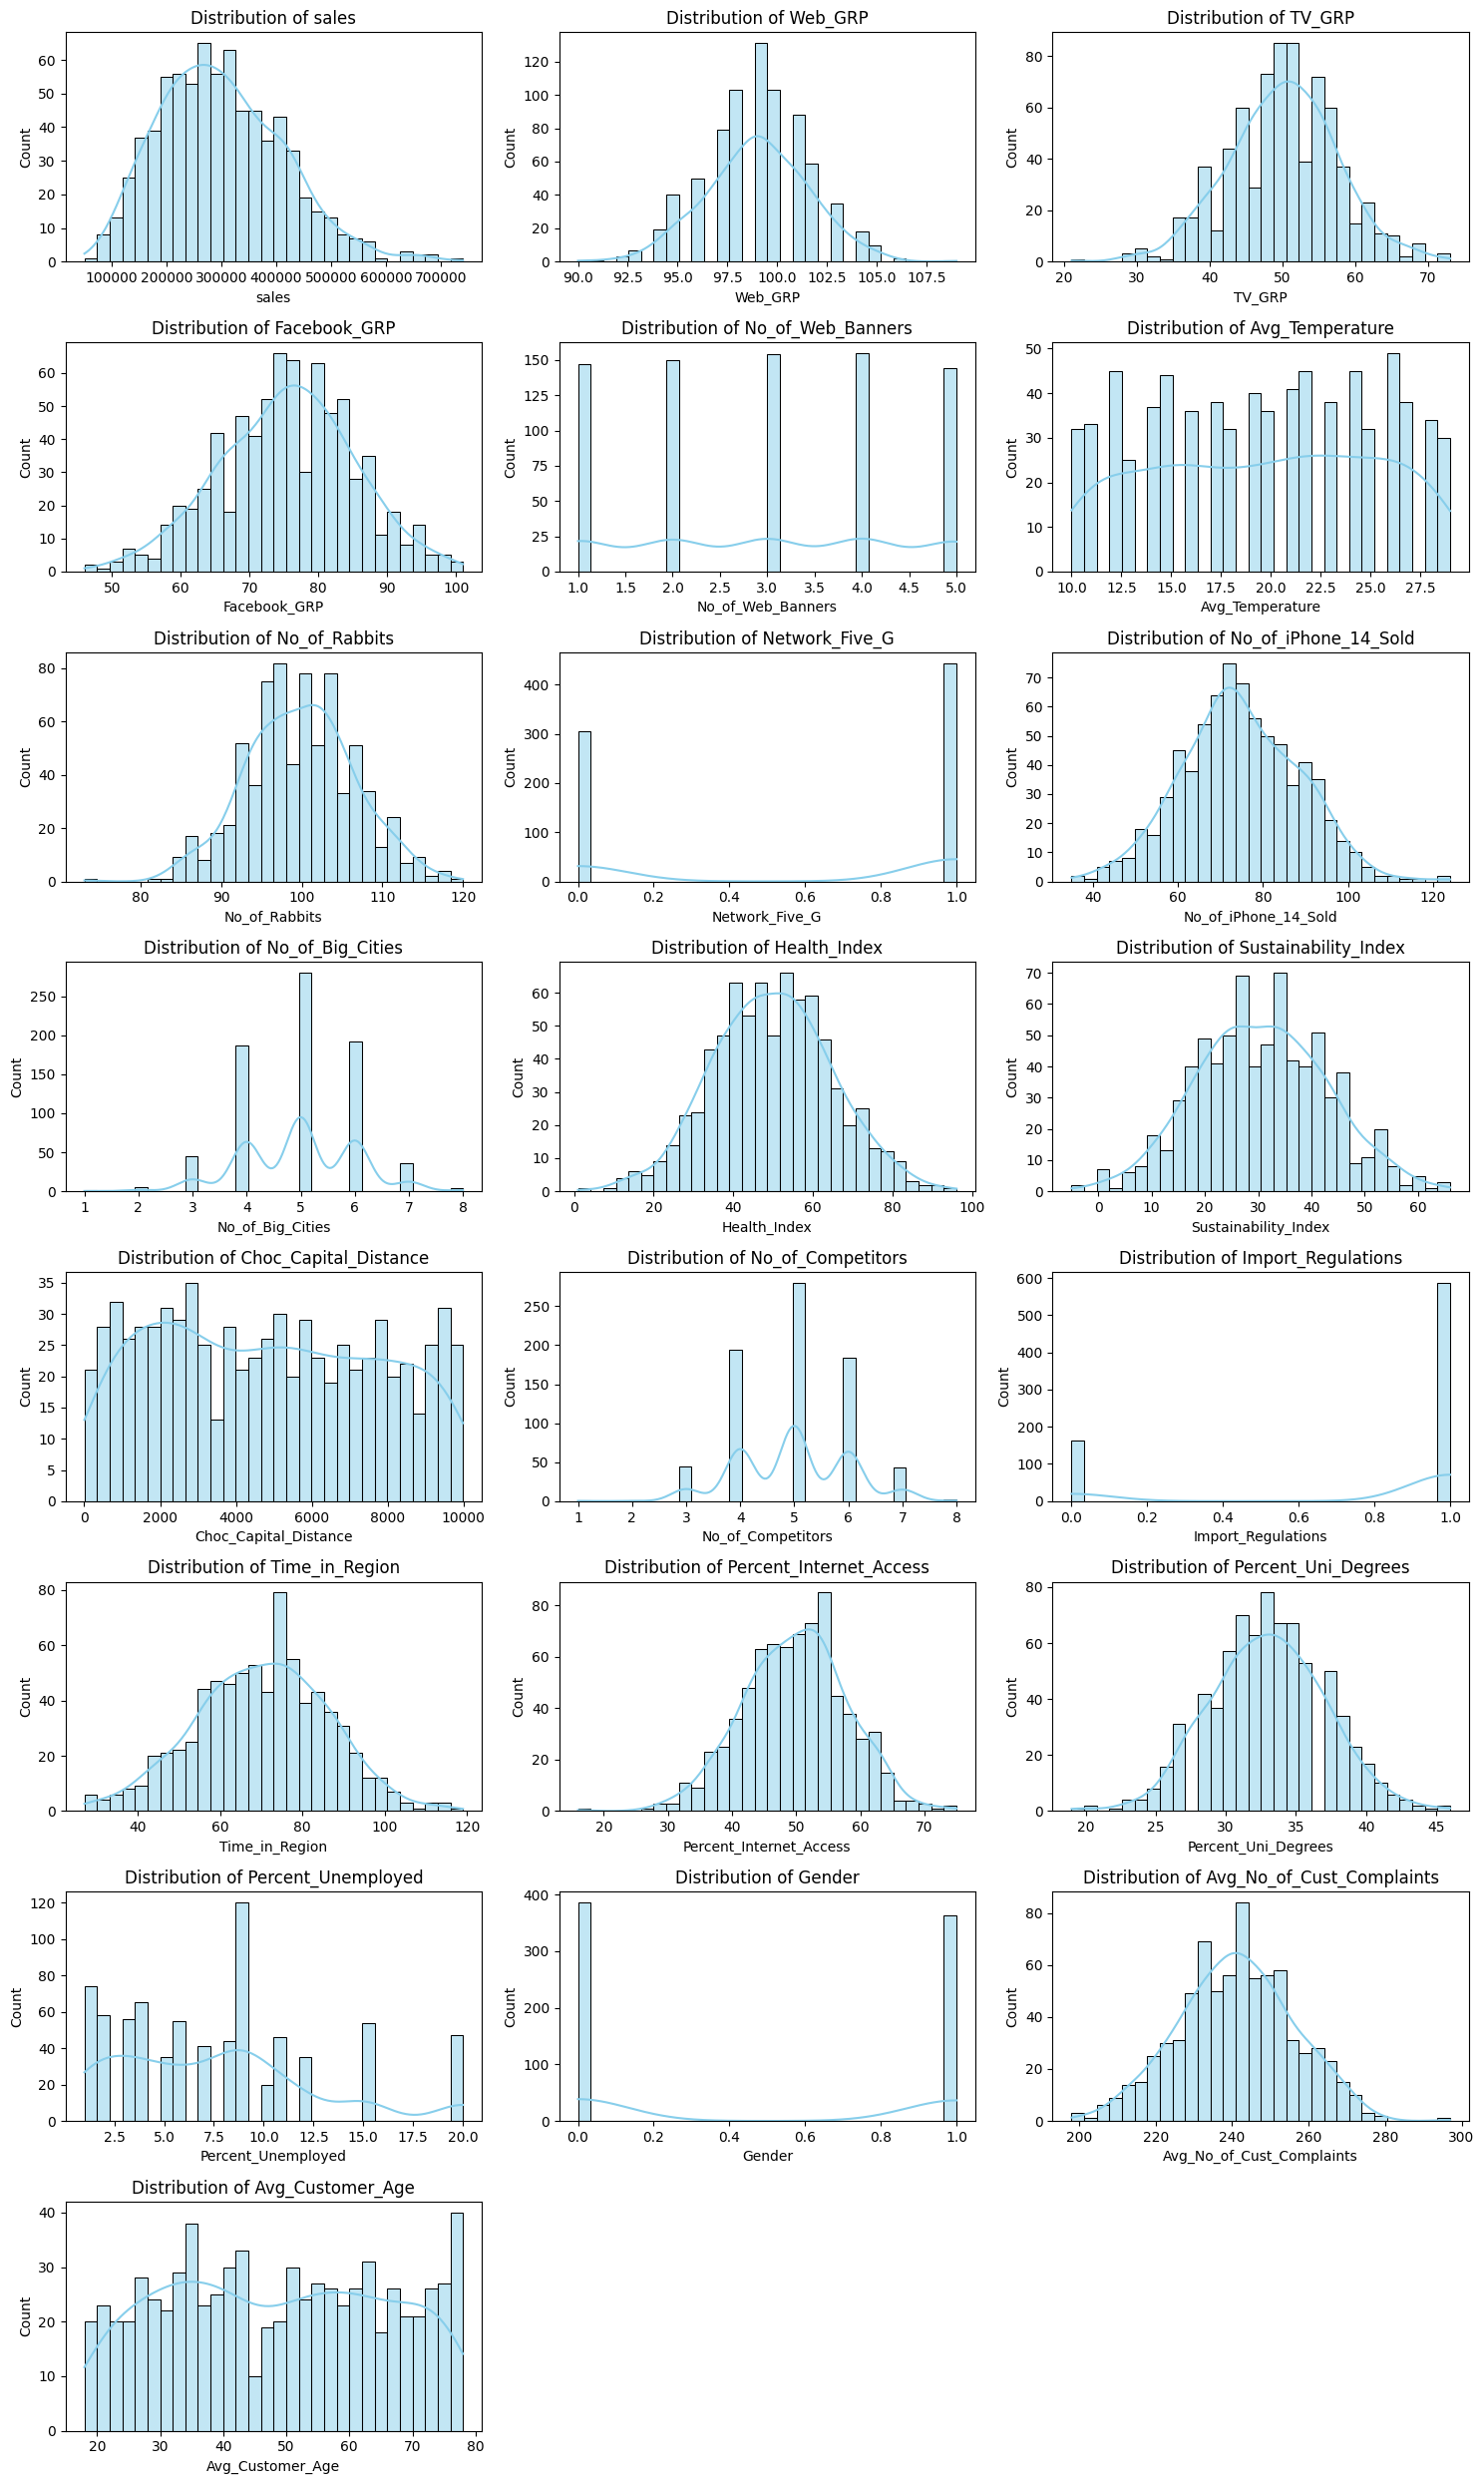

In [15]:
# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# 1. Distribution of numerical features
plt.figure(figsize=(15, 25))
for i, col in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols)//3 + 1, 3, i+1)
    sns.histplot(df[col], kde=True, color='skyblue', bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

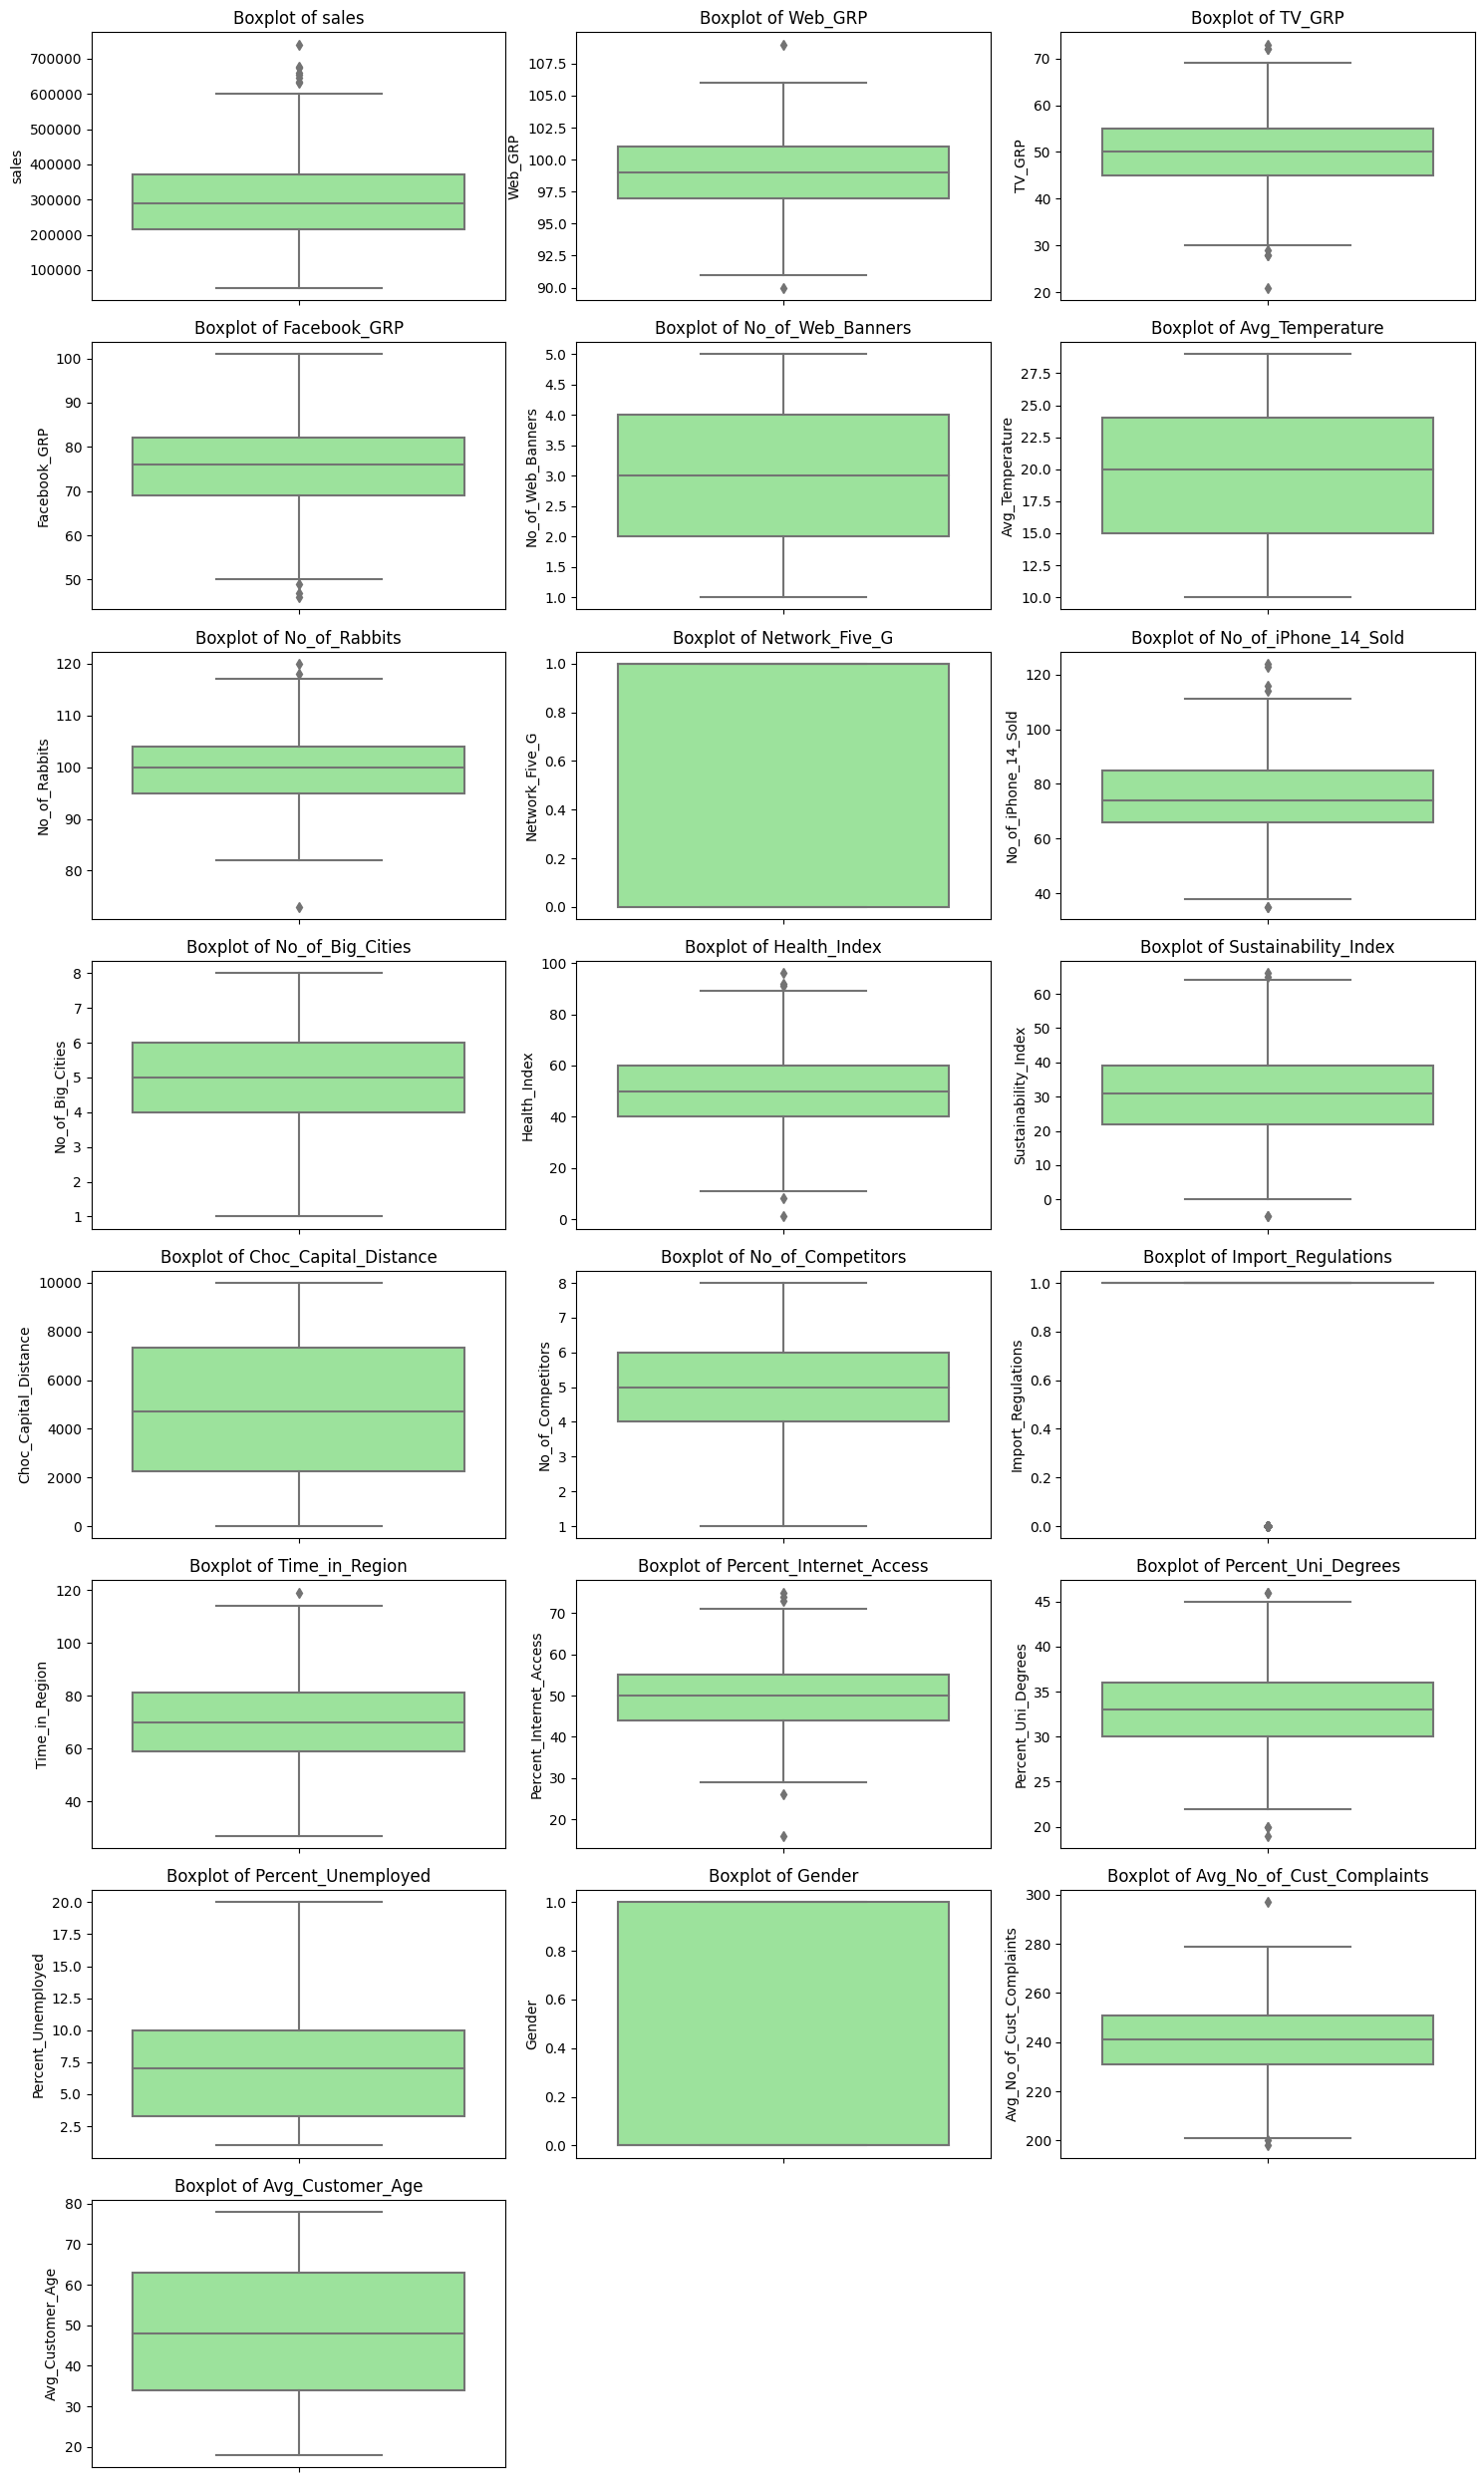

In [16]:
# 2. Boxplots for numerical columns to detect outliers
plt.figure(figsize=(15, 25))
for i, col in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols)//3 + 1, 3, i+1)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

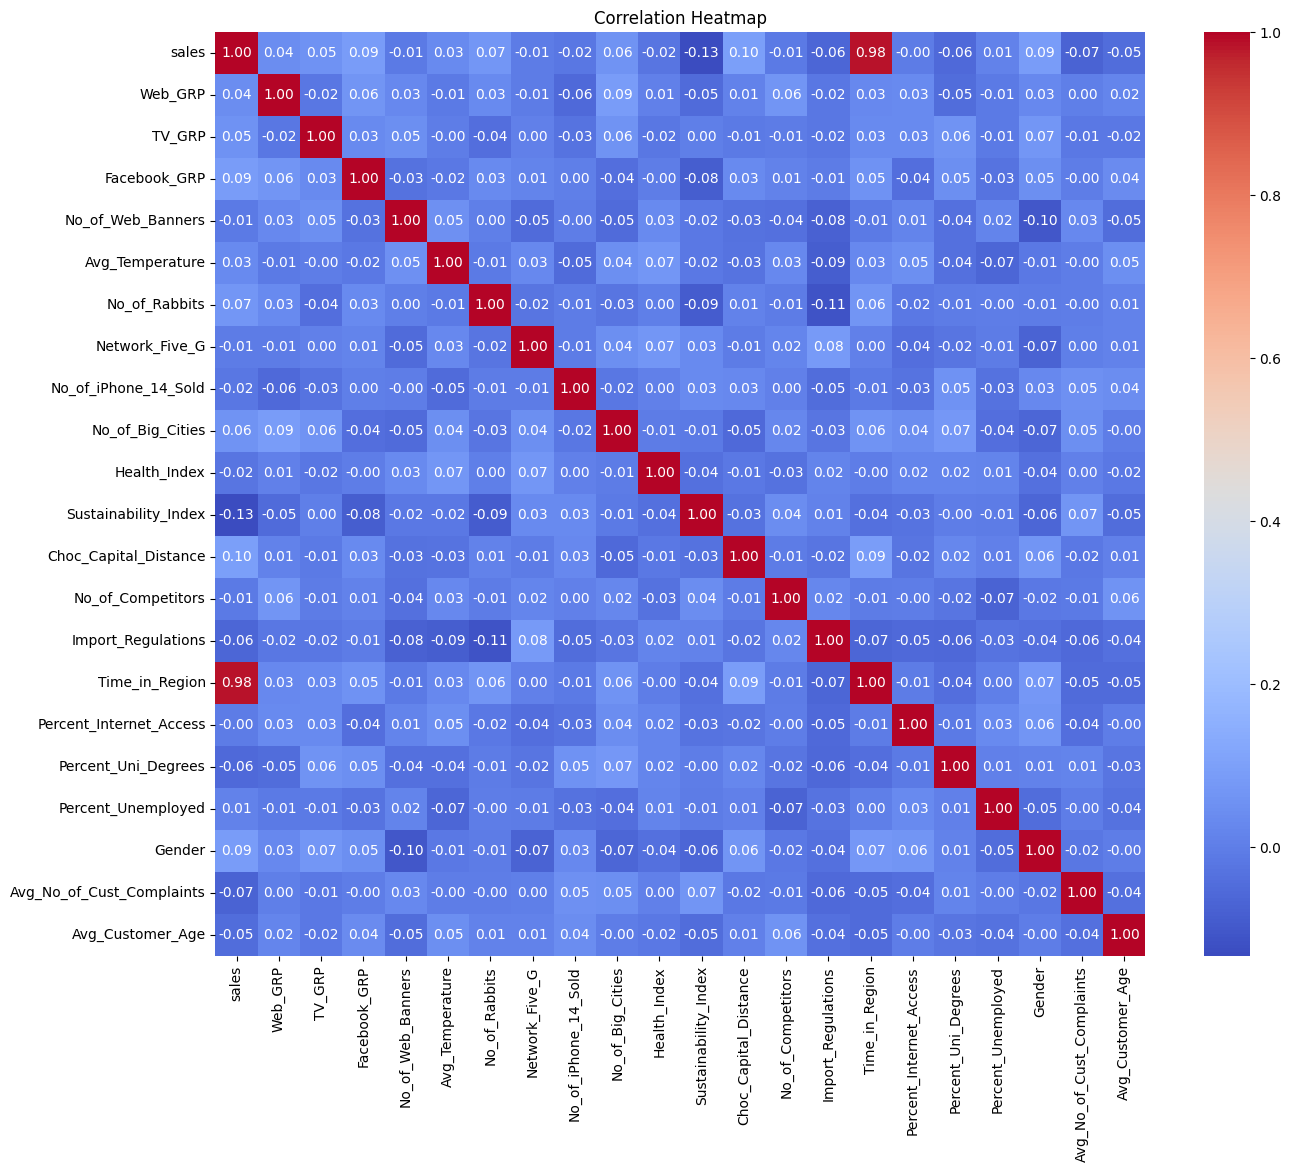

In [17]:
# 3. Correlation heatmap
plt.figure(figsize=(15,12))
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

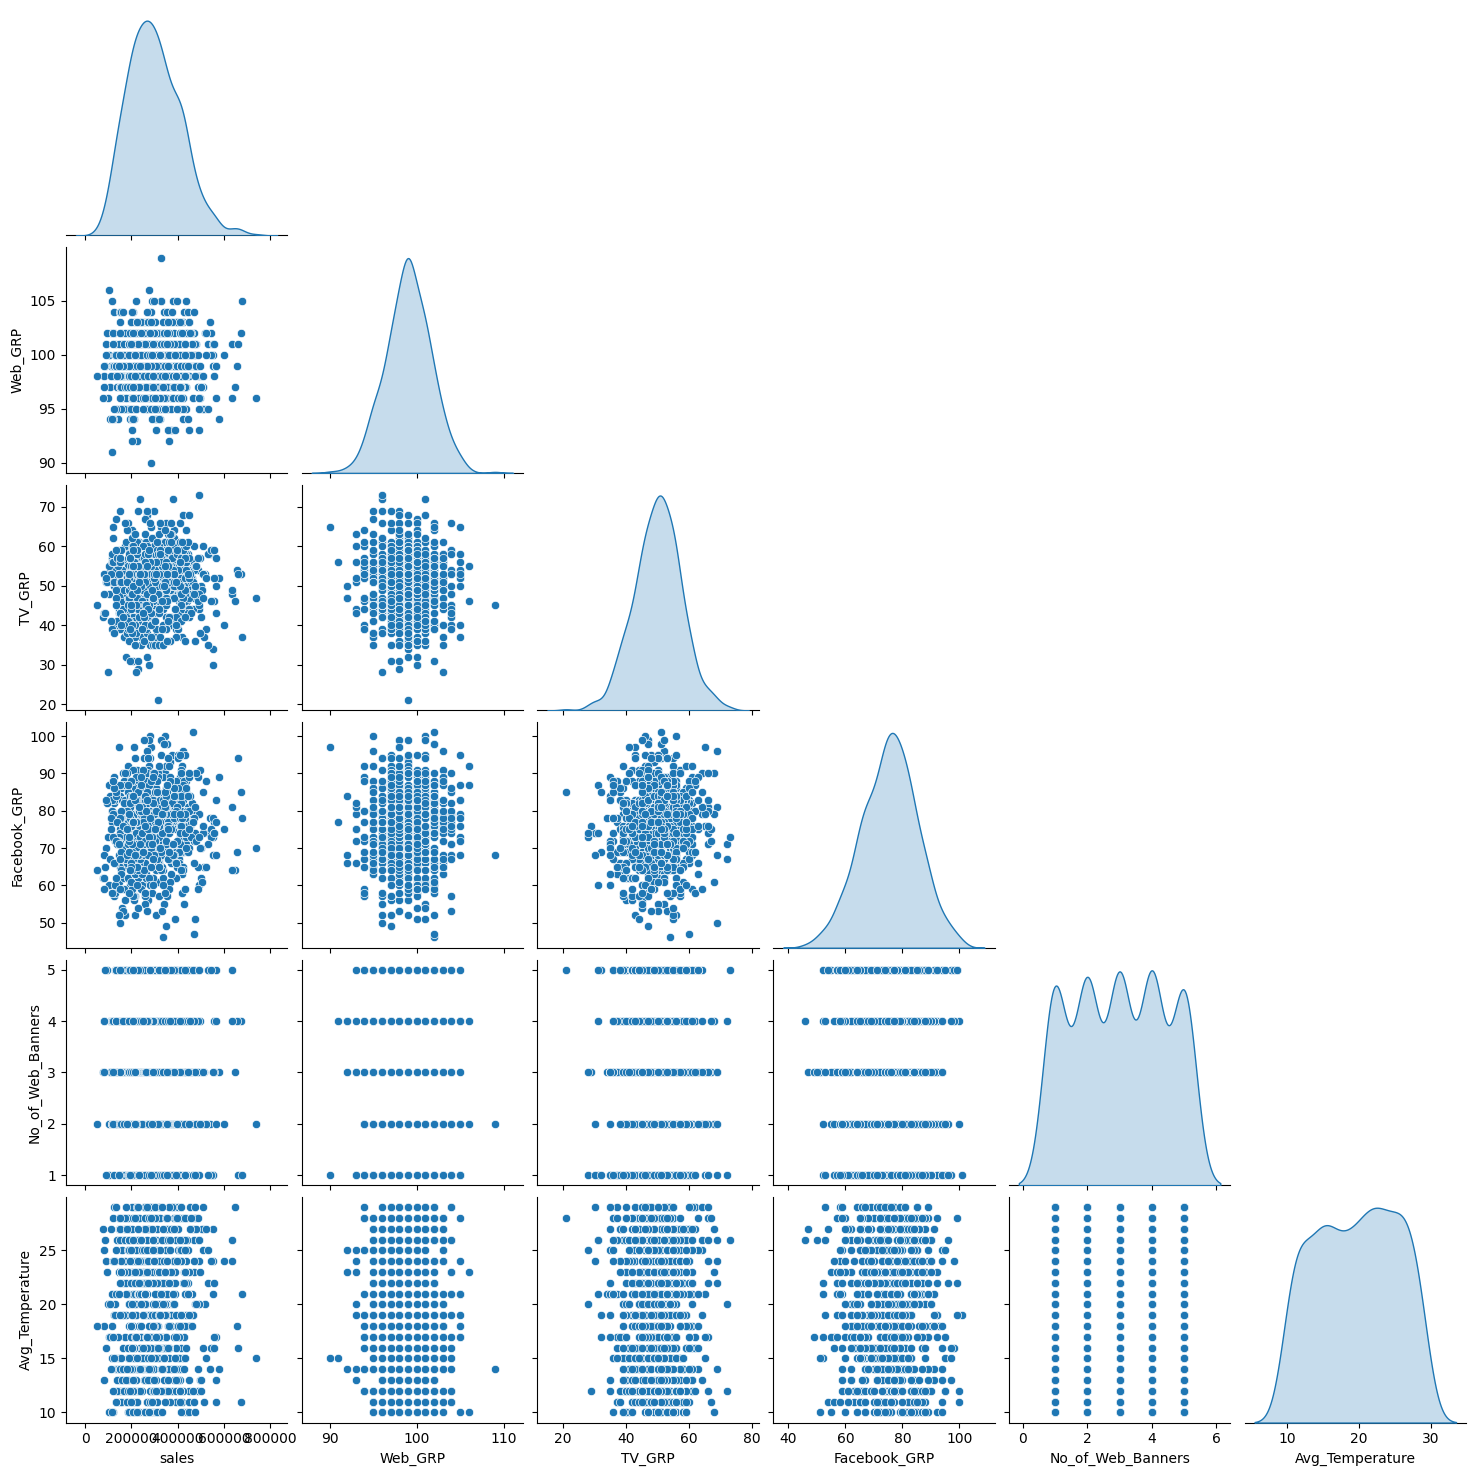

In [18]:
# 4. Pairplot for selected key numerical features
key_features = ['sales', 'Web_GRP', 'TV_GRP', 'Facebook_GRP', 'No_of_Web_Banners', 'Avg_Temperature']
sns.pairplot(df[key_features], diag_kind='kde', corner=True)
plt.show()

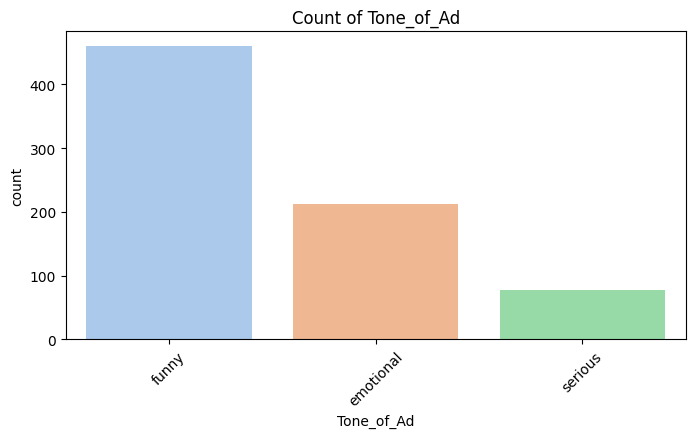

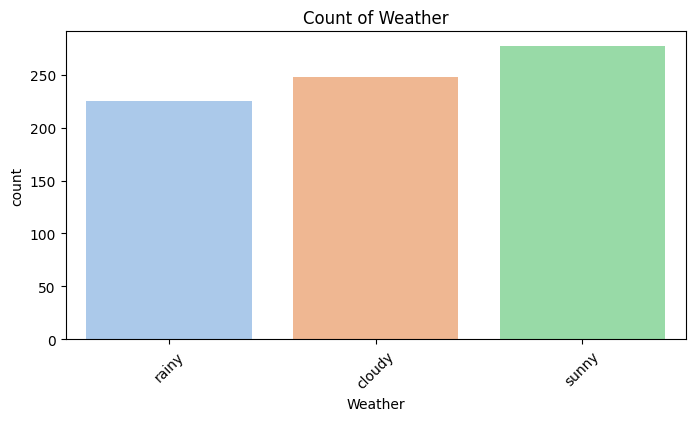

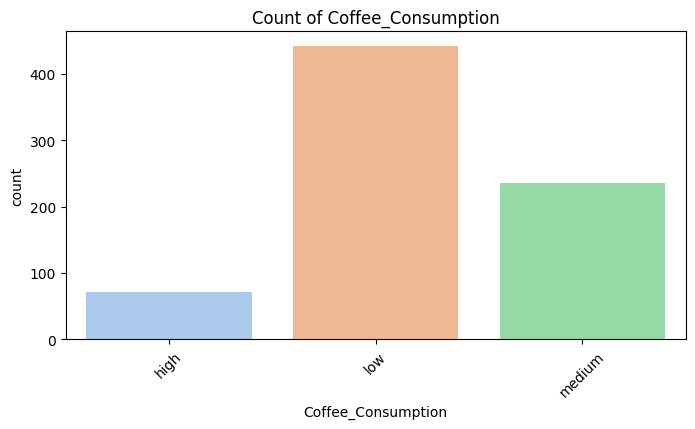

In [19]:
# 5. Categorical features count plots
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col, palette='pastel')
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
    plt.show()


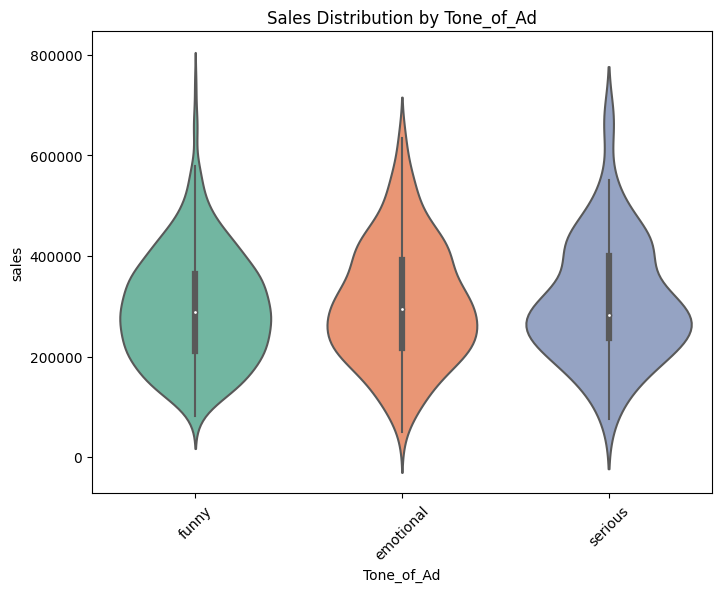

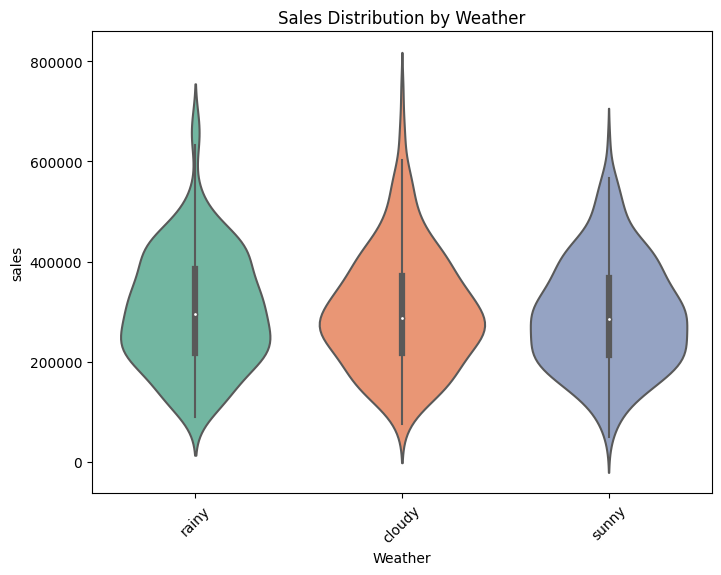

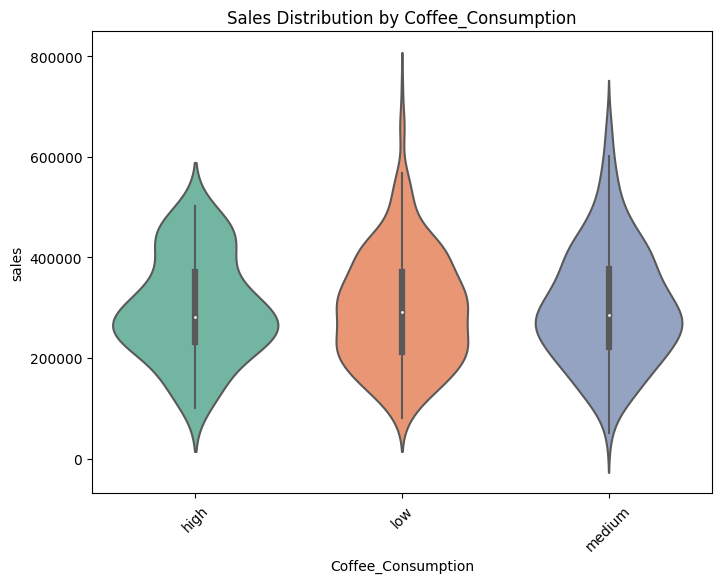

In [20]:
# 6. Violin plots for sales vs categorical features
for col in categorical_cols:
    plt.figure(figsize=(8,6))
    sns.violinplot(data=df, x=col, y='sales', palette='Set2')
    plt.title(f'Sales Distribution by {col}')
    plt.xticks(rotation=45)
    plt.show()

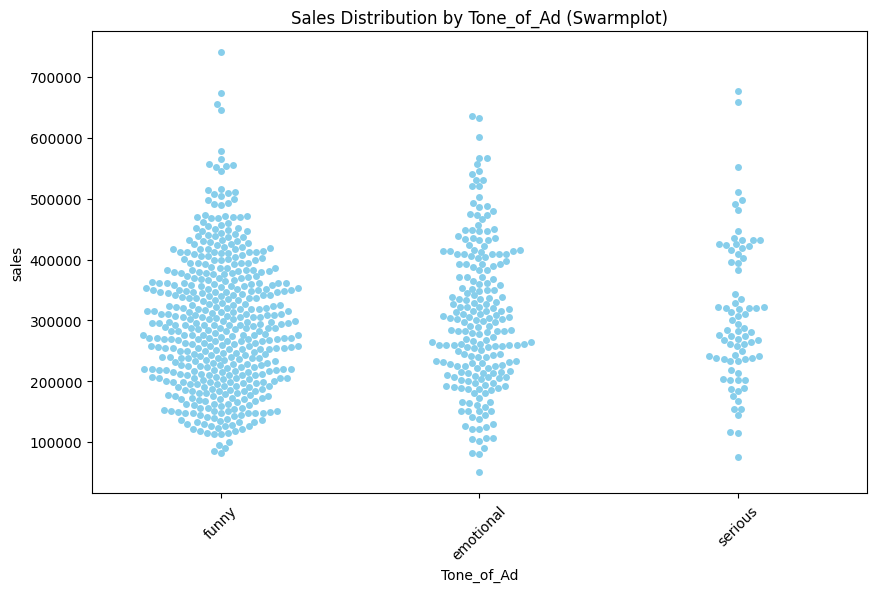

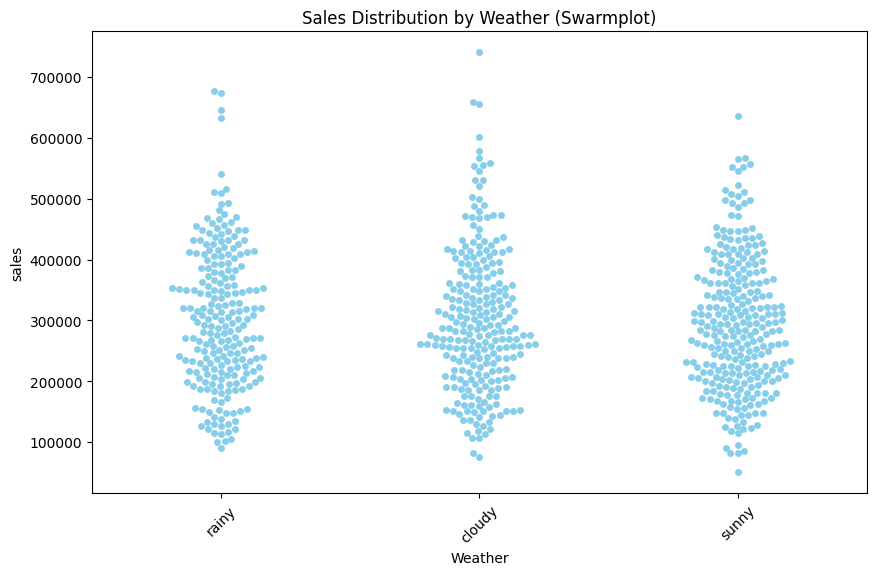

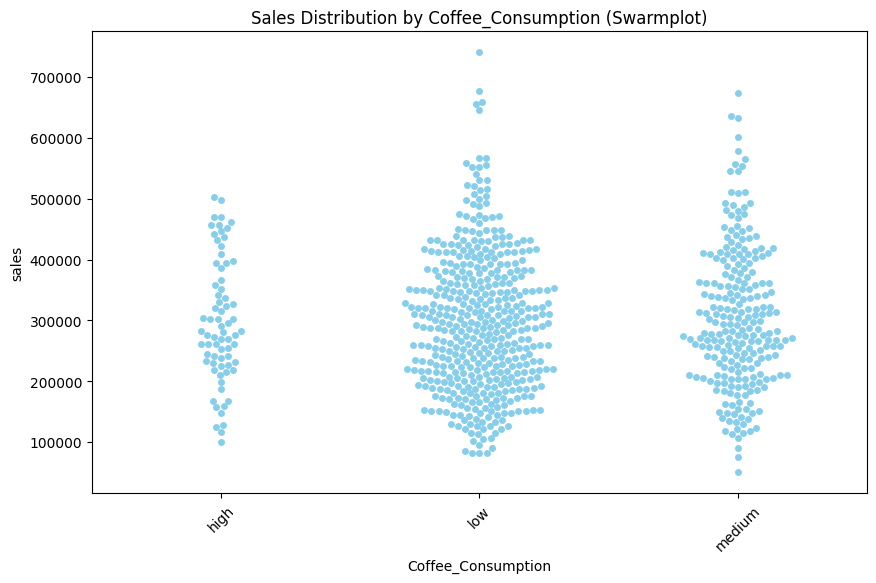

In [21]:
# 7. Swarmplots for sales vs categorical features (alternative)
for col in categorical_cols:
    plt.figure(figsize=(10,6))
    sns.swarmplot(data=df, x=col, y='sales', color='skyblue')
    plt.title(f'Sales Distribution by {col} (Swarmplot)')
    plt.xticks(rotation=45)
    plt.show()

In [22]:
# 8. Interactive scatter plot using Plotly
fig = px.scatter(df, x='TV_GRP', y='sales', color='Tone_of_Ad',
                 size='No_of_Web_Banners', hover_data=['Web_GRP', 'Facebook_GRP'],
                 title='Sales vs TV_GRP with Tone of Ad and Web Banners')
fig.show()

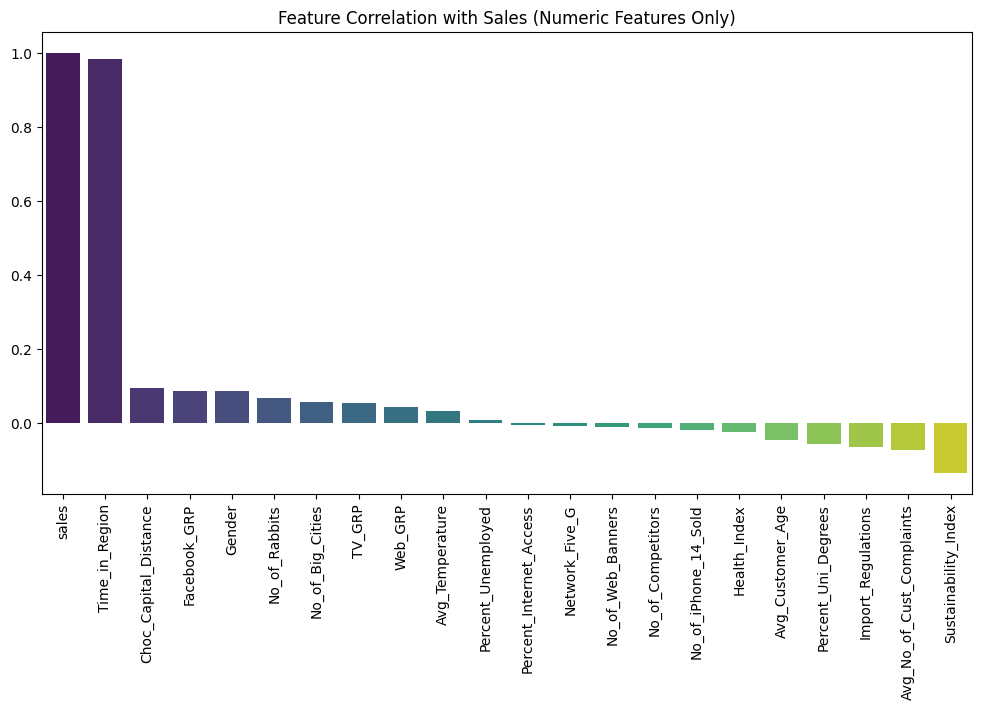

In [23]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation with sales
sales_corr = numeric_df.corr()['sales'].sort_values(ascending=False)

# Plot correlation with sales
plt.figure(figsize=(12,6))
sns.barplot(x=sales_corr.index, y=sales_corr.values, palette='viridis')
plt.xticks(rotation=90)
plt.title('Feature Correlation with Sales (Numeric Features Only)')
plt.show()


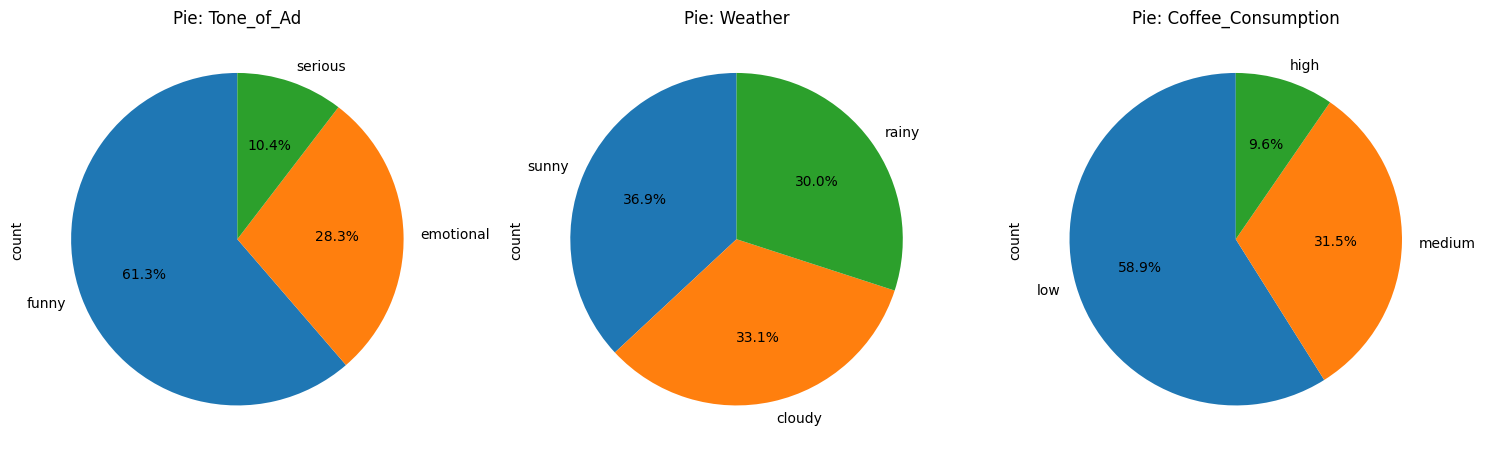

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='pie', ax=axes[idx], autopct='%1.1f%%', startangle=90)
    axes[idx].set_title(f'Pie: {col}')
plt.tight_layout()
plt.show()

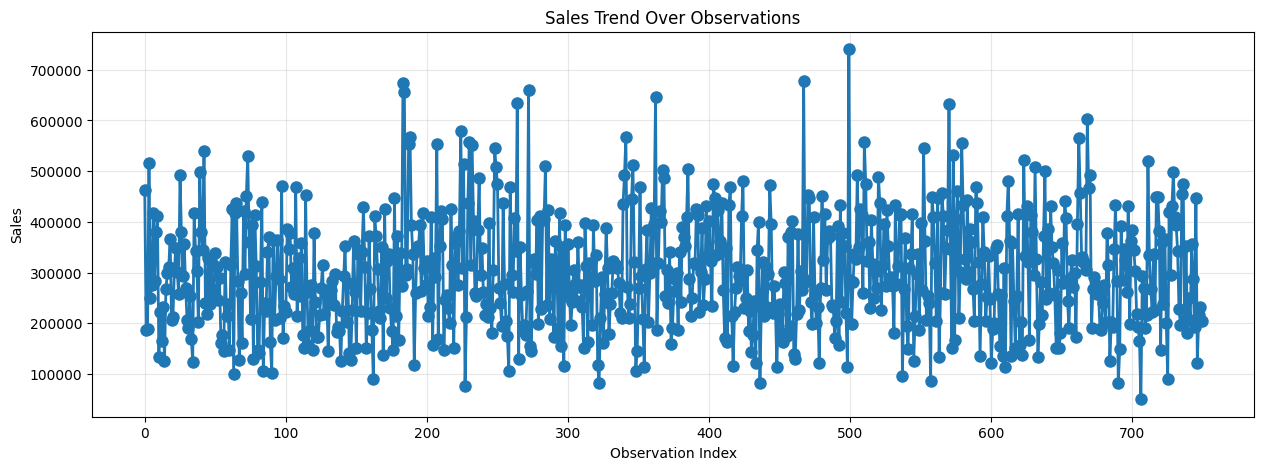

In [25]:
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['sales'], marker='o', linewidth=2, markersize=8)
plt.title('Sales Trend Over Observations')
plt.xlabel('Observation Index')
plt.ylabel('Sales')
plt.grid(True, alpha=0.3)
plt.show()

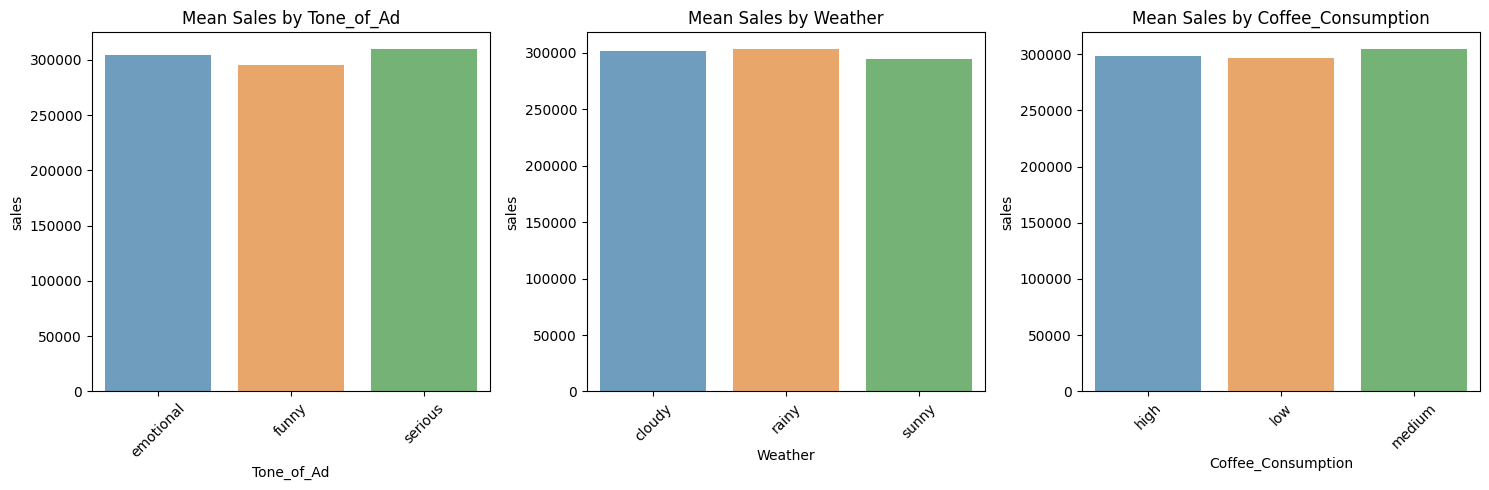

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, col in enumerate(categorical_cols):
    df_grouped = df.groupby(col)['sales'].mean().reset_index()
    sns.barplot(x=col, y='sales', data=df_grouped, ax=axes[idx], alpha=0.7)
    axes[idx].set_title(f'Mean Sales by {col}')
    axes[idx].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

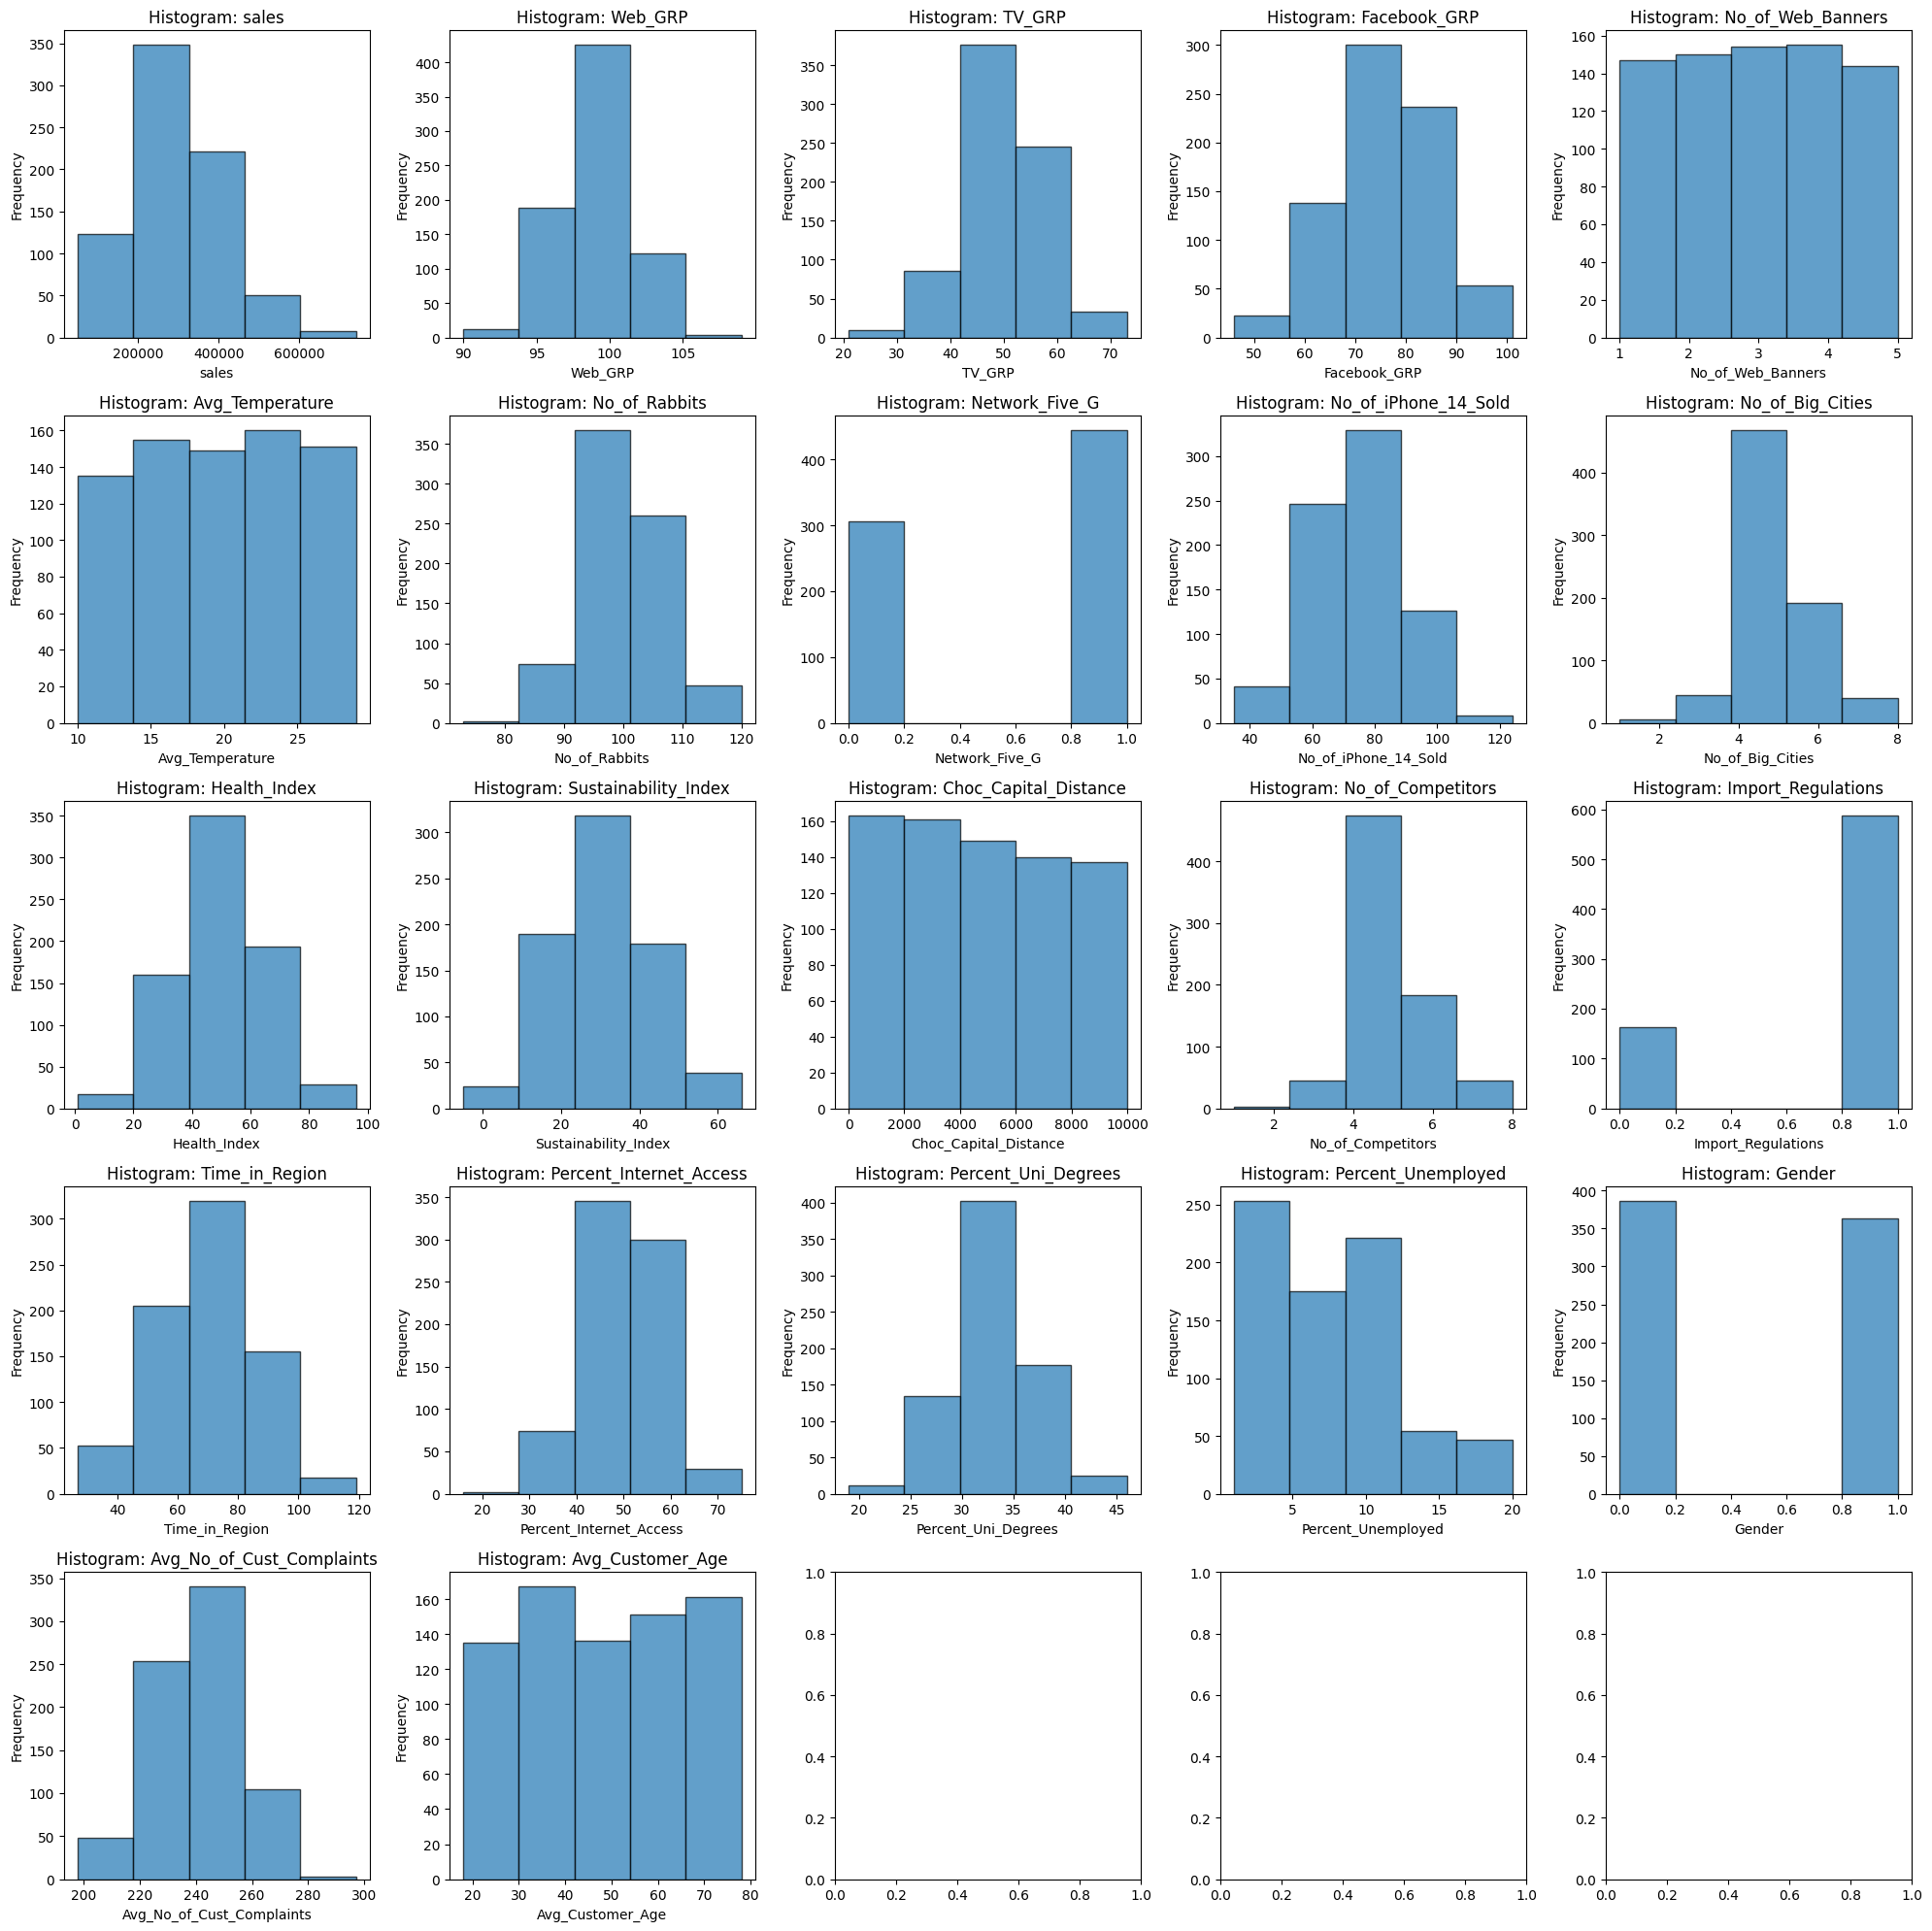

In [27]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
axes = axes.ravel()
for idx, col in enumerate(numerical_cols):
    if idx < len(axes):
        axes[idx].hist(df[col], bins=5, alpha=0.7, edgecolor='black')
        axes[idx].set_title(f'Histogram: {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
plt.tight_layout()
plt.show()


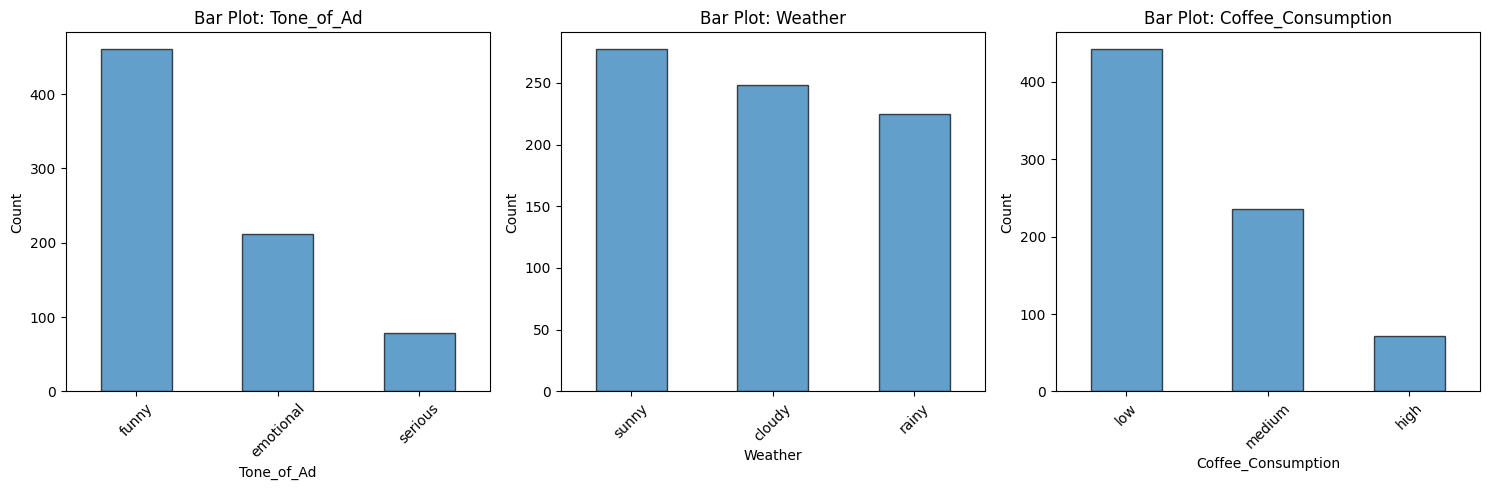

In [28]:
categorical_cols = ['Tone_of_Ad', 'Weather', 'Coffee_Consumption']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, col in enumerate(categorical_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[idx], alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'Bar Plot: {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

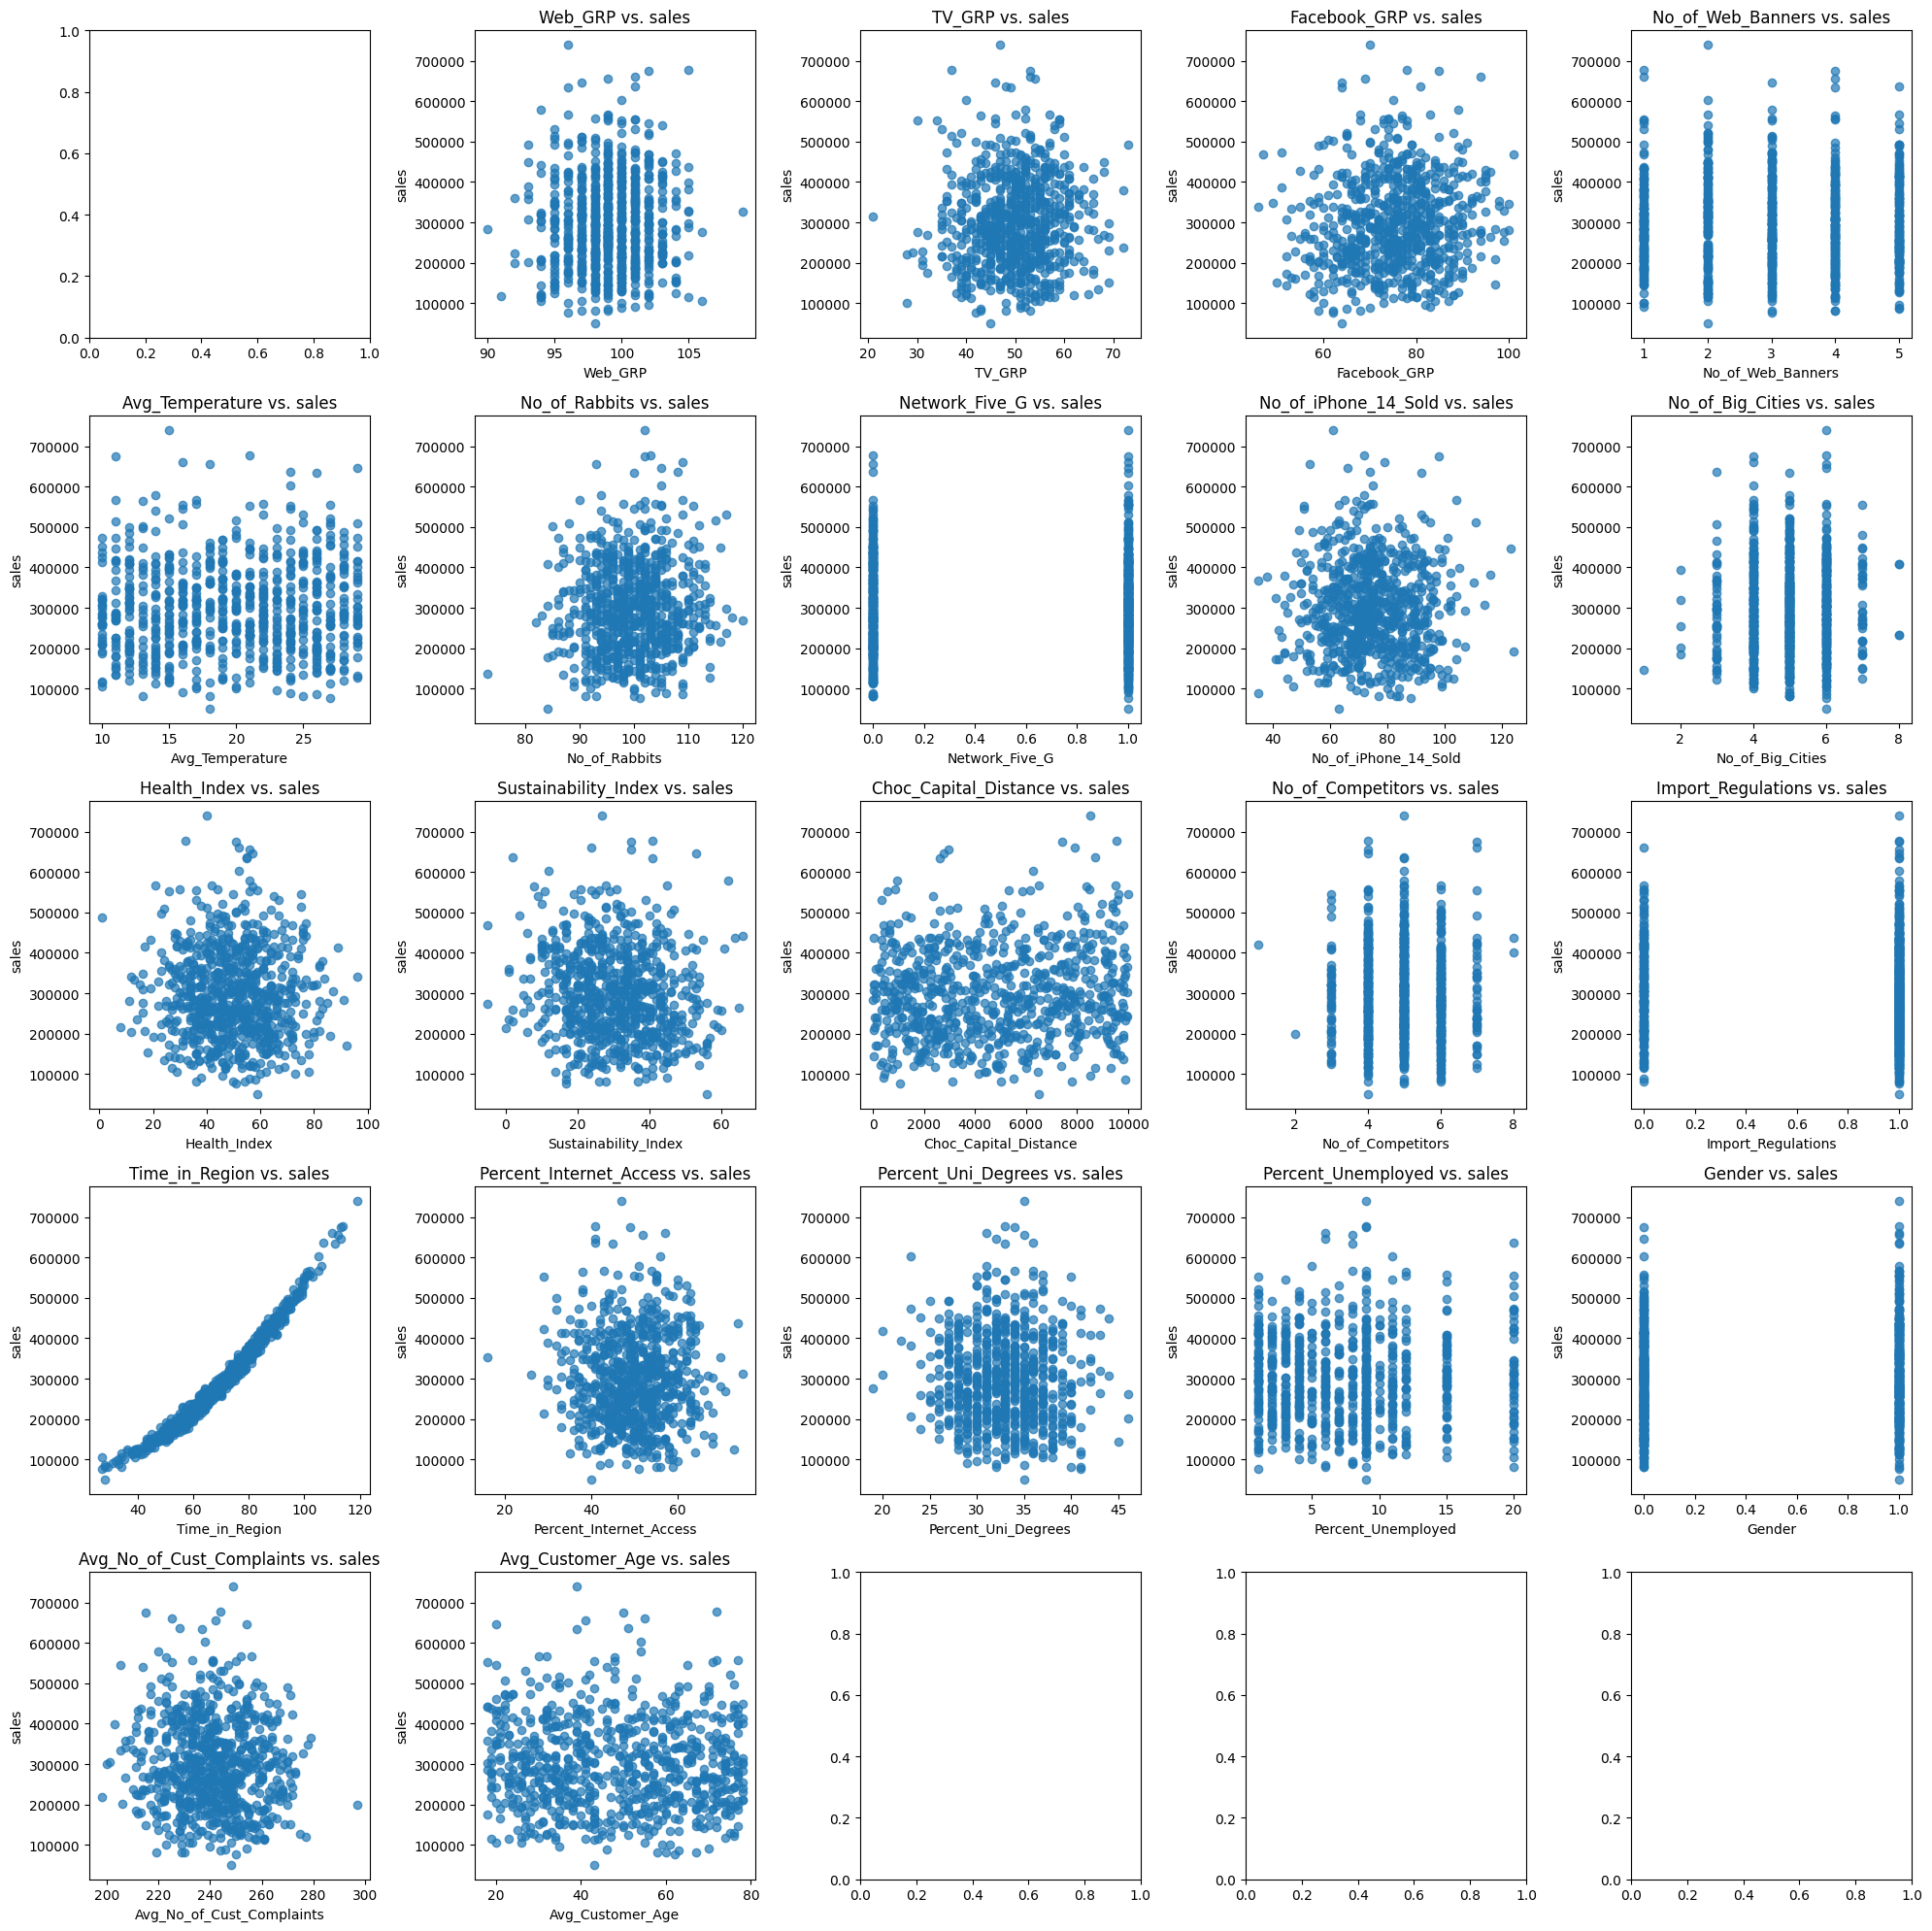

In [29]:
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
axes = axes.ravel()
sales_col = 'sales'
for idx, col in enumerate(numerical_cols):
    if col != sales_col and idx < len(axes):
        axes[idx].scatter(df[col], df[sales_col], alpha=0.7)
        axes[idx].set_title(f'{col} vs. {sales_col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel(sales_col)
plt.tight_layout()
plt.show()

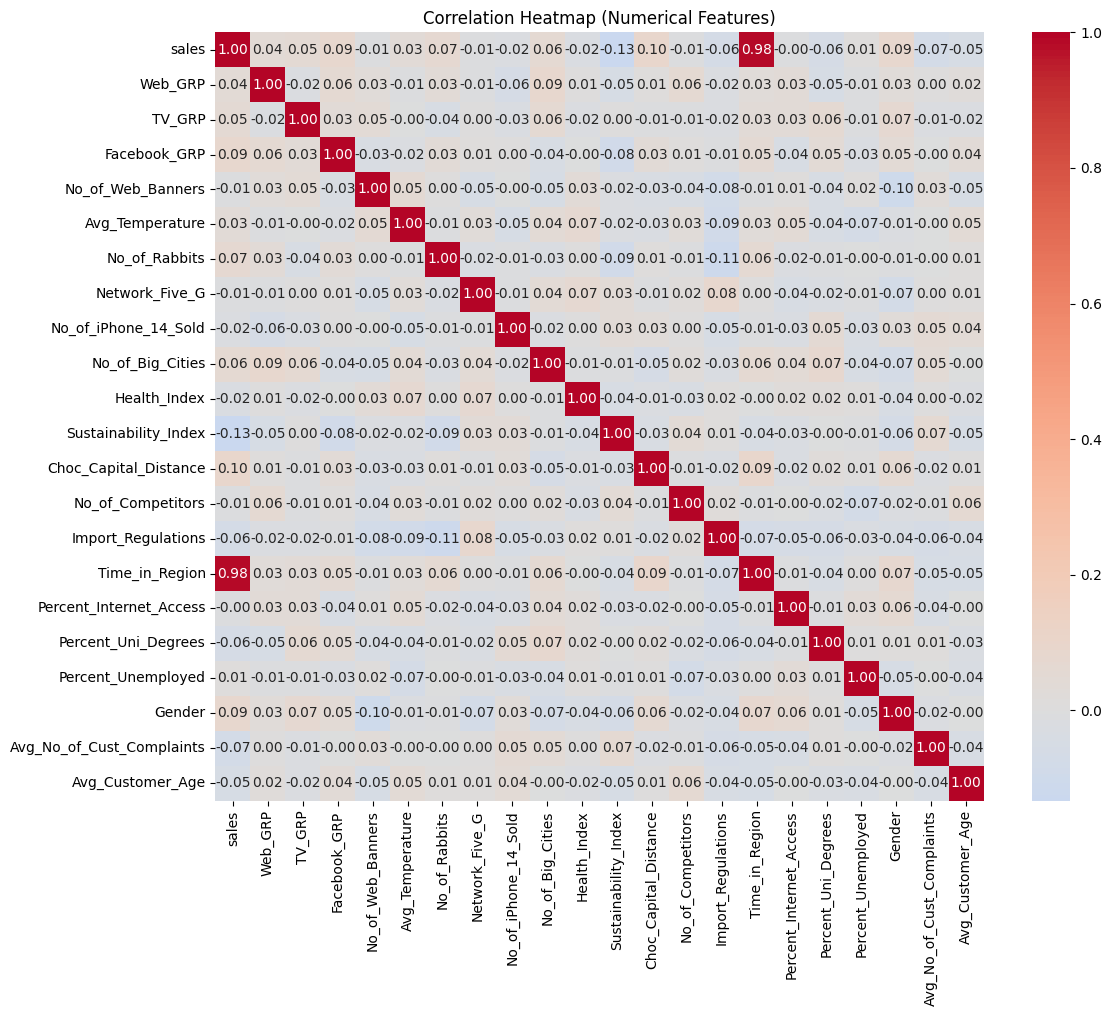

In [30]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', center=0, square=True, fmt='.2f')
plt.title('Correlation Heatmap (Numerical Features)')
plt.tight_layout()
plt.show()

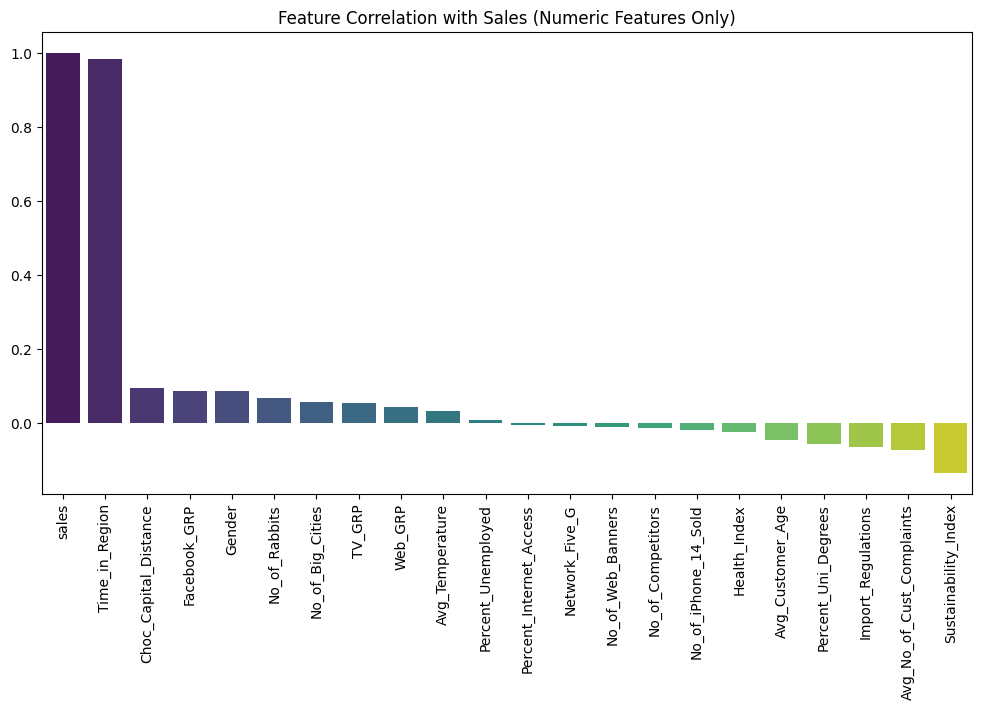

In [31]:
# Select only numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation with sales
sales_corr = numeric_df.corr()['sales'].sort_values(ascending=False)

# Plot correlation with sales
plt.figure(figsize=(12,6))
sns.barplot(x=sales_corr.index, y=sales_corr.values, palette='viridis')
plt.xticks(rotation=90)
plt.title('Feature Correlation with Sales (Numeric Features Only)')
plt.show()


## ML Algorithms

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

In [33]:
target = 'sales'

# Features (exclude target)
X = df.drop(columns=[target])
y = df[target]


In [34]:
# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns

# Label encode categorical columns
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define regression models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=200),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42, n_estimators=200),
    'Support Vector Regressor': SVR()
}

In [35]:
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred) * 100  # in percentage
    results.append({'Model': name, 'R2 (%)': r2, 'RMSE': rmse})


                      Model     R2 (%)           RMSE
5         Gradient Boosting  99.359105    9373.034844
4             Random Forest  98.873073   12428.956520
3             Decision Tree  98.338887   15089.900227
2          Lasso Regression  96.818258   20884.272295
0         Linear Regression  96.818066   20884.900183
1          Ridge Regression  96.804267   20930.138360
6  Support Vector Regressor  -0.027807  117097.390110


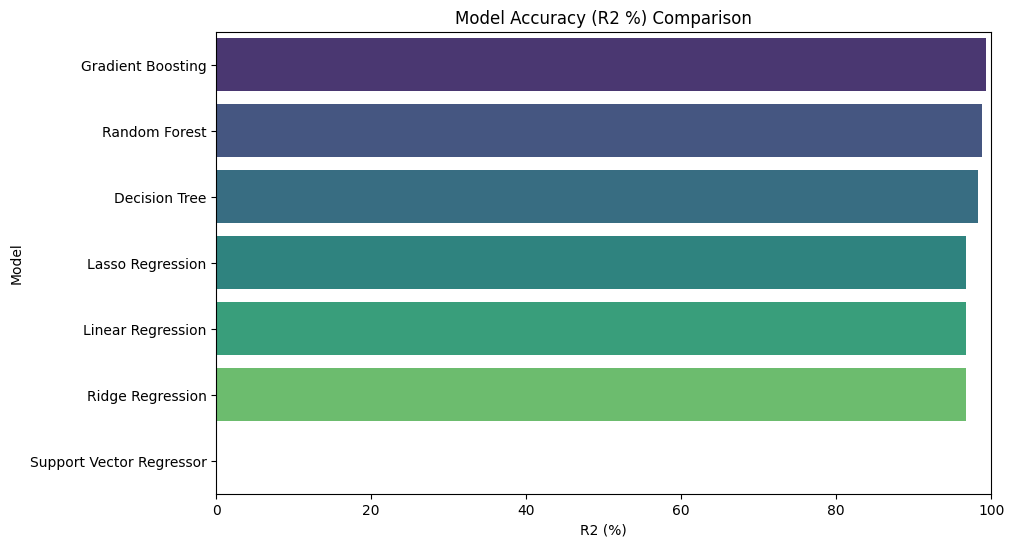

In [36]:
results_df = pd.DataFrame(results).sort_values(by='R2 (%)', ascending=False)
print(results_df)

# Bar plot of R2
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x='R2 (%)', y='Model', palette='viridis')
plt.title('Model Accuracy (R2 %) Comparison')
plt.xlabel('R2 (%)')
plt.ylabel('Model')
plt.xlim(0, 100)
plt.show()

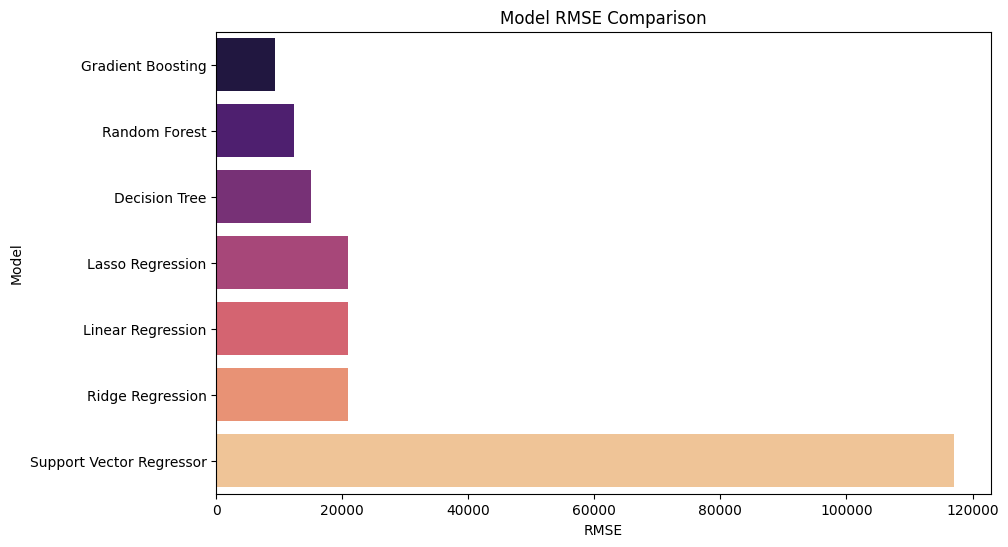

In [37]:
# Bar plot of RMSE
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x='RMSE', y='Model', palette='magma')
plt.title('Model RMSE Comparison')
plt.xlabel('RMSE')
plt.ylabel('Model')
plt.show()

In [38]:
test_df=pd.read_csv("/kaggle/input/sweet-regression-prediction-of-chocolate-sales/data_test.csv")

In [39]:
test_df.head()

,Id,Web_GRP,TV_GRP,Facebook_GRP,Tone_of_Ad,No_of_Web_Banners,Weather,Avg_Temperature,No_of_Rabbits,Network_Five_G,No_of_iPhone_14_Sold,No_of_Big_Cities,Health_Index,Sustainability_Index,Choc_Capital_Distance,No_of_Competitors,Import_Regulations,Time_in_Region,Percent_Internet_Access,Percent_Uni_Degrees,Percent_Unemployed,Gender,Coffee_Consumption,Avg_No_of_Cust_Complaints,Avg_Customer_Age,id
0,1,97,47,76,serious,5,sunny,29,93,0,55,5,27,27,154,4,0,76,48,27,9,1,low,242,43,1
1,4,95,53,78,emotional,5,sunny,19,95,0,74,6,49,42,3409,6,1,52,52,37,1,1,low,250,18,4
2,6,97,53,67,emotional,3,sunny,24,92,1,62,4,48,54,4380,6,0,94,42,27,12,1,medium,232,50,6
3,15,96,45,70,serious,4,cloudy,19,102,1,66,4,57,37,9318,3,1,69,56,31,11,0,medium,223,65,15
4,18,101,36,93,funny,5,rainy,26,86,0,63,7,53,25,1232,6,1,66,53,38,3,0,medium,238,18,18


In [40]:
X_test = test_df.drop(columns=["Id","id"], errors="ignore")
categorical_cols = X_test.select_dtypes(include=['object']).columns
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    le.fit(df[col])  
    label_encoders[col] = le
    # Transform test data
    X_test[col] = le.transform(X_test[col])
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)        
test_predictions = model.predict(X_test_scaled)

In [41]:
submission = pd.DataFrame({"Id": test_df["Id"],"Expected": test_predictions})

In [42]:
submission.to_csv("submission.csv", index=False)
print("Submission file saved!")

Submission file saved!


In [43]:
sub_df=pd.read_csv("/kaggle/working/submission.csv")

In [44]:
sub_df.head()
df.head()


,sales,Web_GRP,TV_GRP,Facebook_GRP,Tone_of_Ad,No_of_Web_Banners,Weather,Avg_Temperature,No_of_Rabbits,Network_Five_G,No_of_iPhone_14_Sold,No_of_Big_Cities,Health_Index,Sustainability_Index,Choc_Capital_Distance,No_of_Competitors,Import_Regulations,Time_in_Region,Percent_Internet_Access,Percent_Uni_Degrees,Percent_Unemployed,Gender,Coffee_Consumption,Avg_No_of_Cust_Complaints,Avg_Customer_Age
0,461825.38,99,56,74,funny,4,rainy,21,94,1,58,4,76,26,5390,6,1,92,57,32,7,0,high,235,20
1,187155.94,100,53,74,emotional,2,rainy,21,100,1,52,4,46,33,3822,4,1,54,44,34,9,0,low,246,67
2,188302.23,101,44,88,emotional,4,cloudy,20,88,0,69,4,63,47,2447,5,0,56,50,31,3,1,low,245,77
3,516640.99,102,53,65,funny,2,rainy,20,115,0,63,5,38,32,5051,5,0,98,57,37,4,0,low,224,35
4,250103.04,101,42,73,funny,5,sunny,14,103,0,72,5,68,39,8699,5,1,66,46,33,2,0,low,227,45


In [45]:
y = df["sales"]
X = df.drop(columns=["sales"], errors="ignore")

numeric_features = [
    "Web_GRP", "TV_GRP", "Facebook_GRP", "No_of_Web_Banners",
    "Avg_Temperature", "No_of_Rabbits", "No_of_iPhone_14_Sold",
    "No_of_Big_Cities", "Health_Index", "Sustainability_Index",
    "Choc_Capital_Distance", "No_of_Competitors", "Time_in_Region",
    "Percent_Internet_Access", "Percent_Uni_Degrees", "Percent_Unemployed",
    "Avg_No_of_Cust_Complaints", "Avg_Customer_Age"
]
categorical_features = ["Tone_of_Ad", "Weather"]
ordinal_features = ["Coffee_Consumption"]
binary_features = ["Network_Five_G", "Import_Regulations", "Gender"]

In [46]:
from sklearn.preprocessing import OrdinalEncoder

In [47]:
X[numeric_features] = X[numeric_features].fillna(X[numeric_features].median())
X[categorical_features + ordinal_features] = X[categorical_features + ordinal_features].ffill()
X[binary_features] = X[binary_features].fillna(0)

X[numeric_features] = StandardScaler().fit_transform(X[numeric_features])
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

ordinal_encoder = OrdinalEncoder(categories=[["low","medium","high"]])
X[ordinal_features] = ordinal_encoder.fit_transform(X[ordinal_features].astype(str))

bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(float)

In [48]:
X

,Web_GRP,TV_GRP,Facebook_GRP,No_of_Web_Banners,Avg_Temperature,No_of_Rabbits,Network_Five_G,No_of_iPhone_14_Sold,No_of_Big_Cities,Health_Index,Sustainability_Index,Choc_Capital_Distance,No_of_Competitors,Import_Regulations,Time_in_Region,Percent_Internet_Access,Percent_Uni_Degrees,Percent_Unemployed,Gender,Coffee_Consumption,Avg_No_of_Cust_Complaints,Avg_Customer_Age,Tone_of_Ad_funny,Tone_of_Ad_serious,Weather_rainy,Weather_sunny
0,-0.012294,0.796969,-0.143528,0.715482,0.241622,-0.864925,1,-1.208091,-0.942740,1.761948,-0.381432,0.196011,1.004906,1,1.365260,0.881411,-0.243377,-0.123290,0,2.0,-0.405700,-1.621045,1.0,0.0,1.0,0.0
1,0.371896,0.396884,-0.143528,-0.713576,0.241622,0.029208,1,-1.641272,-0.942740,-0.252884,0.193674,-0.344242,-0.965498,1,-1.000084,-0.725800,0.243377,0.271871,0,0.0,0.324932,1.071784,0.0,0.0,1.0,0.0
2,0.756086,-0.803371,1.286307,0.715482,0.063784,-1.759058,0,-0.413928,-0.942740,0.888854,1.343885,-0.817997,0.019704,0,-0.875593,0.015990,-0.486754,-0.913614,1,0.0,0.258511,1.644726,0.0,0.0,0.0,0.0
3,1.140276,0.396884,-1.062708,-0.713576,0.063784,2.264542,0,-0.847108,0.025828,-0.790172,0.111516,0.079209,0.019704,0,1.738736,0.881411,0.973508,-0.716033,0,0.0,-1.136332,-0.761631,1.0,0.0,1.0,0.0
4,0.756086,-1.070094,-0.245659,1.430011,-1.003241,0.476275,0,-0.197338,0.025828,1.224660,0.686622,1.336125,0.019704,1,-0.253133,-0.478537,0.000000,-1.111194,0,0.0,-0.937068,-0.188689,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745,-0.012294,0.396884,0.877782,0.000953,0.241622,0.327253,1,3.484694,0.025828,1.023176,1.097411,1.348874,0.019704,0,1.303014,0.263253,-0.973508,-1.308775,1,2.0,0.856300,1.415549,0.0,0.0,0.0,1.0
746,0.756086,1.597139,1.286307,0.000953,-1.358916,-0.864925,0,-0.269534,0.994397,-0.185723,-0.545748,0.006165,0.019704,1,-1.996019,0.386884,1.947016,0.271871,1,0.0,2.383985,-0.818925,1.0,0.0,1.0,0.0
747,-0.396484,-2.003626,-0.756314,0.000953,0.419460,1.519431,0,-1.135895,0.025828,0.687371,-0.134958,1.580066,1.004906,1,-0.626609,-1.220326,-0.486754,-1.111194,1,0.0,-1.003489,0.326959,0.0,0.0,0.0,1.0
748,-0.780674,0.130161,0.571389,-1.428106,0.419460,0.029208,0,-0.847108,0.025828,0.015760,0.686622,0.142262,0.019704,1,-0.502117,-0.849431,-0.973508,0.864614,0,2.0,-0.870647,-0.303277,0.0,0.0,0.0,1.0


In [49]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:
model = GradientBoostingRegressor()
model.fit(X_train, y_train)

GradientBoostingRegressor()

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [52]:
y_pred = model.predict(X_valid)
print("MAE:", mean_absolute_error(y_valid, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_valid, y_pred)))
print("R2:", r2_score(y_valid, y_pred))

MAE: 5435.88721915223
RMSE: 9966.014956291501
R2: 0.9927544828757784


In [53]:
test_df=pd.read_csv("/kaggle/input/sweet-regression-prediction-of-chocolate-sales/data_test.csv")

In [54]:
test_df.head()

,Id,Web_GRP,TV_GRP,Facebook_GRP,Tone_of_Ad,No_of_Web_Banners,Weather,Avg_Temperature,No_of_Rabbits,Network_Five_G,No_of_iPhone_14_Sold,No_of_Big_Cities,Health_Index,Sustainability_Index,Choc_Capital_Distance,No_of_Competitors,Import_Regulations,Time_in_Region,Percent_Internet_Access,Percent_Uni_Degrees,Percent_Unemployed,Gender,Coffee_Consumption,Avg_No_of_Cust_Complaints,Avg_Customer_Age,id
0,1,97,47,76,serious,5,sunny,29,93,0,55,5,27,27,154,4,0,76,48,27,9,1,low,242,43,1
1,4,95,53,78,emotional,5,sunny,19,95,0,74,6,49,42,3409,6,1,52,52,37,1,1,low,250,18,4
2,6,97,53,67,emotional,3,sunny,24,92,1,62,4,48,54,4380,6,0,94,42,27,12,1,medium,232,50,6
3,15,96,45,70,serious,4,cloudy,19,102,1,66,4,57,37,9318,3,1,69,56,31,11,0,medium,223,65,15
4,18,101,36,93,funny,5,rainy,26,86,0,63,7,53,25,1232,6,1,66,53,38,3,0,medium,238,18,18


In [55]:
X_test = test_df.drop(columns=["Id","id"], errors="ignore")
X_test[numeric_features] = X_test[numeric_features].fillna(X[numeric_features].median())
X_test[categorical_features + ordinal_features] = X_test[categorical_features + ordinal_features].ffill()
X_test[binary_features] = X_test[binary_features].fillna(0)

scaler = StandardScaler().fit(X[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

X_test = pd.get_dummies(X_test, columns=categorical_features, drop_first=True)

for col in X.columns:
    if col not in X_test.columns:
        X_test[col] = 0

X_test = X_test[X.columns]


In [56]:
ordinal_encoder = OrdinalEncoder(categories=[["low","medium","high"]])
ordinal_encoder.fit(df[ordinal_features].astype(str))
X_test[ordinal_features] = ordinal_encoder.transform(X_test[ordinal_features].astype(str))
bool_cols = X_test.select_dtypes(include='bool').columns
X_test[bool_cols] = X_test[bool_cols].astype(float)

In [57]:
y_pred_test = model.predict(X_test)

# Create submission
submission = pd.DataFrame({"Id": test_df["Id"],"Expected": y_pred_test})

submission.to_csv("gb_submission.csv", index=False)

In [58]:
sub_gb=pd.read_csv("/kaggle/working/gb_submission.csv")

In [59]:
sub_gb.head()

,Id,Expected
0,1,644395.631697
1,4,644395.631697
2,6,644395.631697
3,15,643325.819277
4,18,643325.819277


## Thank you...pls upvote!!!!